# Quantitative Investment Framework: Cluster-Based Portfolio Strategy

This notebook implements a comprehensive quantitative investment framework that uses **clustering techniques** to identify market regimes and construct optimal portfolios. The approach combines:

- **Technical Analysis**: Feature engineering using TA-Lib indicators
- **Dimensionality Reduction**: PCA for feature transformation
- **Clustering Algorithms**: Multiple clustering methods to identify market regimes
- **Portfolio Optimization**: Markowitz optimization for portfolio construction
- **Performance Analysis**: Comprehensive financial metrics and backtesting

---

## Overview

This framework analyzes financial time series data, extracts technical features, applies clustering to identify different market regimes, and constructs portfolios optimized for each regime.

## Framework Information

> **Note**: This is a quantitative investment framework for research and educational purposes.  
> For professional applications, consider consulting with experienced mentors and practitioners.

---

## Workflow

1. **Data Collection**: Download historical market data
2. **Feature Engineering**: Extract technical indicators and statistical features
3. **Data Preprocessing**: Normalize and transform features using PCA
4. **Clustering**: Identify market regimes using various clustering algorithms
5. **Portfolio Construction**: Optimize weights for each cluster/regime
6. **Backtesting**: Evaluate performance on train and test sets
7. **Analysis**: Compare strategies using financial metrics

---

# Getting Started

This section covers the initial setup, including library installation and imports.

## 0.00 | Setup & Imports

Install required libraries and import necessary modules for data processing, analysis, and visualization.

In [ ]:
# Install necessary libraries
# yfinance: For downloading financial market data
# TA-Lib: Technical Analysis Library for technical indicators
%pip install yfinance TA-Lib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 13.9 MB/s eta 0:00:00


In [ ]:
# ============================================================================
# Import all necessary libraries
# ============================================================================

# Data handling and manipulation
import pandas as pd
import numpy as np

# Data sources - Financial market data
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics & time series analysis
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.stattools import coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# Technical Analysis - TA-Lib for technical indicators
import talib

# Machine learning / preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, OPTICS, 
    MeanShift, SpectralClustering, AffinityPropagation, Birch
)
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import BayesianGaussianMixture

# Optimization
from scipy.optimize import minimize

## Import Custom Framework Functions

Load custom functions from the framework notebook. These functions handle:
- Data preprocessing and feature engineering
- Technical analysis indicators
- Portfolio optimization
- Performance metrics calculation

In [ ]:
# Mount Google Drive (for Colab environment)
# This allows access to files stored in Google Drive
from google.colab import drive
drive.mount('/content/drive')   # ✅ always mount here

# Navigate to the Colab Notebooks folder where framework functions are stored
%cd /content/drive/MyDrive/Colab Notebooks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks


In [ ]:
# Import custom framework functions from the framework notebook
# This loads all the helper functions for feature engineering, analysis, and portfolio optimization
%run Quant_Invest_Framework_1.ipynb

---

## 01.00 | Configuration Parameters

Define key parameters for data download, analysis period, and train/test split.

In [ ]:

# ============================================================================
# Configuration Parameters
# ============================================================================

# Tickers to download from Yahoo Finance
# - AAPL: Apple Inc.
# - SPY: SPDR S&P 500 ETF Trust
# - ^GSPC: S&P 500 Index
tickers_download = ["AAPL", "SPY", "^GSPC"]

# Tickers of interest for analysis (subset of downloaded tickers)
tickers_interested = ["AAPL", "SPY"]

# Date ranges for data download
# Extended range for feature engineering (needs historical data for indicators)
start_date_download = "2010-01-01"
end_date_download = "2026-01-01"

# Date range for actual analysis period
start_date = "2018-01-01"
end_date = "2026-01-01"

# Train/test split date - data before this date is used for training
split_date = "2024-01-01"

---

## 02.00 | Data Collection & Preparation

Download historical market data and compute log returns for analysis.

In [ ]:
# Download historical market data from Yahoo Finance
# df_data_raw: Data for analysis period (2018-2026)
df_data_raw = yf.download(tickers_download, start=start_date, end=end_date, auto_adjust=False)

# df_data_raw_long: Extended historical data for feature engineering (2010-2026)
# This longer period is needed to compute technical indicators that require historical lookback
df_data_raw_long = yf.download(tickers_download, start=start_date_download, end=end_date_download, auto_adjust=False)

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


### Data Preview

Inspect the downloaded data to verify structure and content.

In [ ]:
# Display the extended historical data structure
# This shows OHLCV (Open, High, Low, Close, Volume) data for all tickers
df_data_raw_long

Price        Adj Close                                Close              \
Ticker            AAPL         SPY        ^GSPC        AAPL         SPY   
Date                                                                      
2010-01-04    6.424606   85.515633  1132.989990    7.643214  113.330002   
2010-01-05    6.435712   85.741974  1136.520020    7.656429  113.629997   
2010-01-06    6.333344   85.802361  1137.140015    7.534643  113.709999   
2010-01-07    6.321636   86.164558  1141.689941    7.520714  114.190002   
2010-01-08    6.363664   86.451302  1144.979980    7.570714  114.570000   
...                ...         ...          ...         ...         ...   
2025-08-29  232.139999  645.049988  6460.259766  232.139999  645.049988   
2025-09-02  229.720001  640.270020  6415.540039  229.720001  640.270020   
2025-09-03  238.470001  643.739990  6448.259766  238.470001  643.739990   
2025-09-04  239.779999  649.119995  6502.080078  239.779999  649.119995   
2025-09-05  239.690002  647.239990  6481.500000  239.690002  647.239990   

Price                          High                                  Low  \
Ticker            ^GSPC        AAPL         SPY        ^GSPC        AAPL   
Date                                                                       
2010-01-04  1132.989990    7.660714  113.389999  1133.869995    7.585000   
2010-01-05  1136.520020    7.699643  113.680000  1136.630005    7.616071   
2010-01-06  1137.140015    7.686786  113.989998  1139.189941    7.526786   
2010-01-07  1141.689941    7.571429  114.330002  1142.459961    7.466071   
2010-01-08  1144.979980    7.571429  114.620003  1145.390015    7.466429   
...                 ...         ...         ...          ...         ...   
2025-08-29  6460.259766  233.380005  647.840027  6491.759766  231.369995   
2025-09-02  6415.540039  230.850006  640.489990  6416.540039  226.970001   
2025-09-03  6448.259766  238.850006  644.210022  6453.669922  234.360001   
2025-09-04  6502.080078  239.899994  649.150024  6502.540039  236.740005   
2025-09-05  6481.500000  241.320007  652.210022  6532.649902  238.490005   

Price                                      Open                           \
Ticker             SPY        ^GSPC        AAPL         SPY        ^GSPC   
Date                                                                       
2010-01-04  111.510002  1116.560059    7.622500  112.370003  1116.560059   
2010-01-05  112.849998  1129.660034    7.664286  113.260002  1132.660034   
2010-01-06  113.430000  1133.949951    7.656429  113.519997  1135.709961   
2010-01-07  113.180000  1131.319946    7.562500  113.500000  1136.270020   
2010-01-08  113.660004  1136.219971    7.510714  113.889999  1140.520020   
...                ...          ...         ...         ...          ...   
2025-08-29  643.140015  6444.569824  232.509995  647.469971  6489.279785   
2025-09-02  634.919983  6360.580078  229.250000  637.500000  6401.509766   
2025-09-03  640.460022  6416.169922  237.210007  642.669983  6445.819824   
2025-09-04  643.510010  6445.979980  238.449997  644.419983  6456.600098   
2025-09-05  643.330017  6443.979980  240.000000  651.479980  6529.080078   

Price          Volume                         
Ticker           AAPL        SPY       ^GSPC  
Date                                          
2010-01-04  493729600  118944600  3991400000  
2010-01-05  601904800  111579900  2491020000  
2010-01-06  552160000  116074400  4972660000  
2010-01-07  477131200  131091100  5270680000  
2010-01-08  447610800  126402800  4389590000  
...               ...        ...         ...  
2025-08-29   39418400   74522200  4234840000  
2025-09-02   44075600   81983500  4784000000  
2025-09-03   66427800   70820900  4465360000  
2025-09-04   47549400   65219200  4670770000  
2025-09-05   54837300   84970600  5066120000  

[3943 rows x 18 columns]

In [ ]:
# Compute log returns (logarithmic returns) for selected tickers
# Log returns are preferred in quantitative finance because:
# 1. They are time-additive (sum of daily returns = total return)
# 2. They are approximately normally distributed for small returns
# 3. They are symmetric (log(1/r) = -log(r))
df_log_returns_TARGET = np.log(
    df_data_raw_long['Adj Close'][tickers_download] /
    df_data_raw_long['Adj Close'][tickers_download].shift(1)
)

In [ ]:
# Preview log returns for AAPL
# First value will be NaN due to the shift operation
df_log_returns_TARGET['AAPL'].head()

,AAPL
Date,
2010-01-04,NaN
2010-01-05,0.001727
2010-01-06,-0.016034
2010-01-07,-0.001850
2010-01-08,0.006626


---

## 03.00 | Data Visualization & Exploratory Analysis

Perform comprehensive exploratory data analysis to understand:
- Price dynamics and trends
- Return distributions and stylized facts
- Asset relationships and correlations
- Volume and liquidity patterns

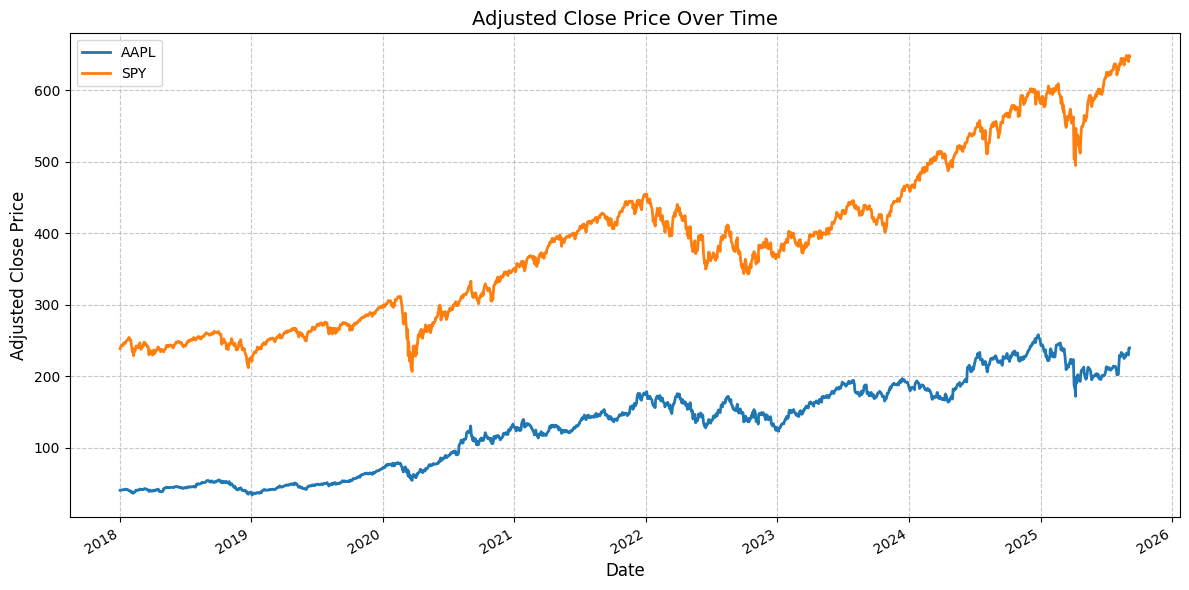

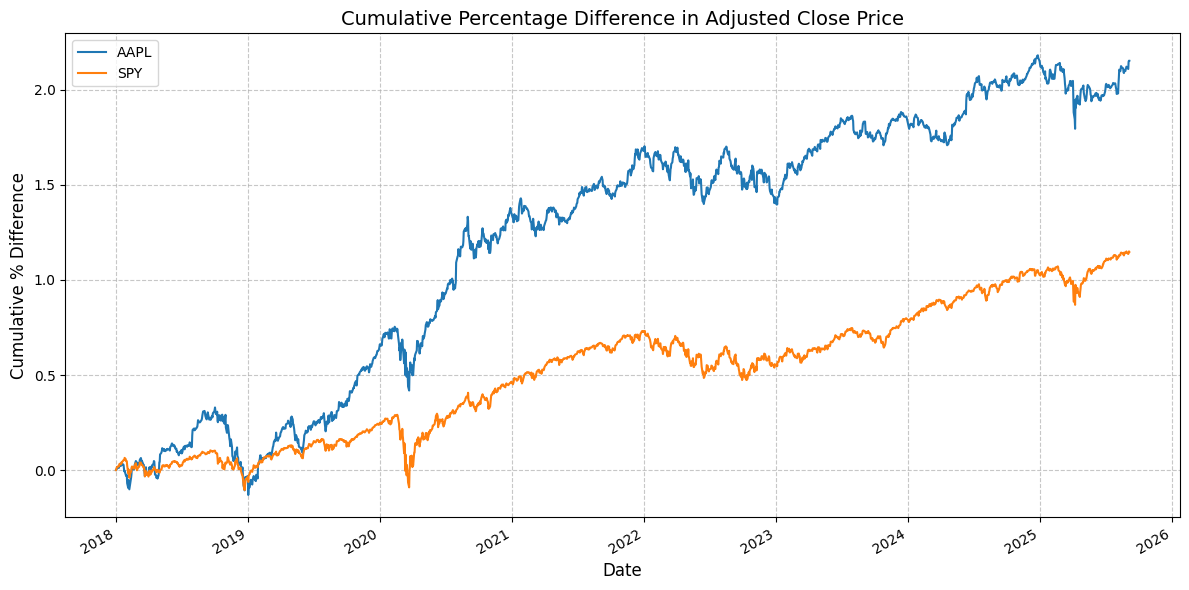

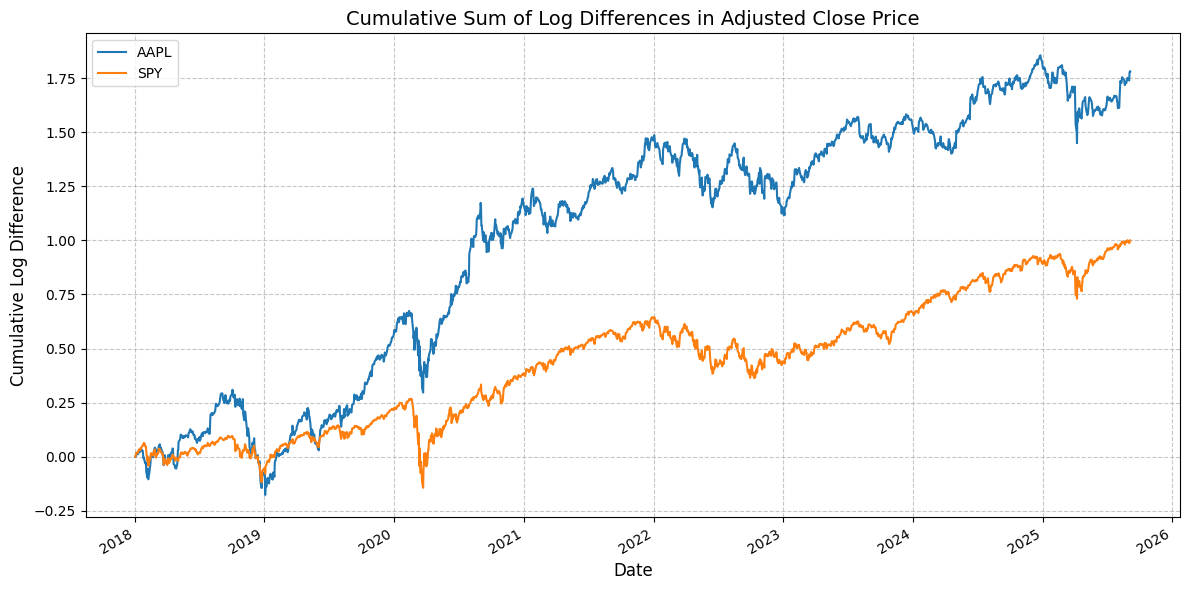

In [ ]:
# Analyze price trends and patterns for selected tickers
Analyze_price(tickers_interested, df_data_raw)

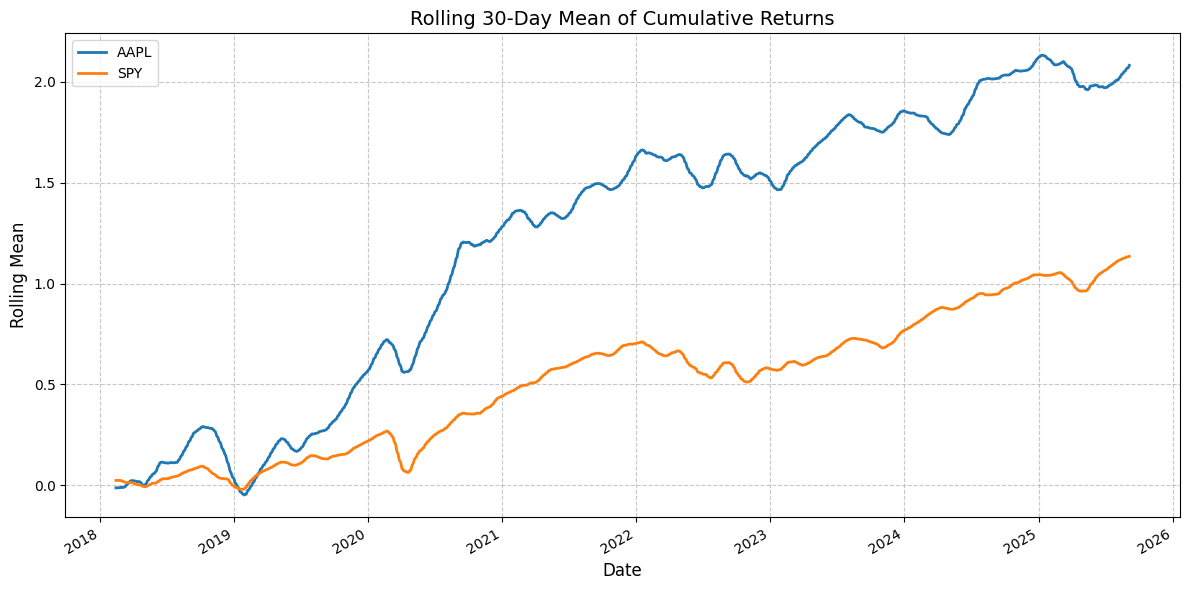

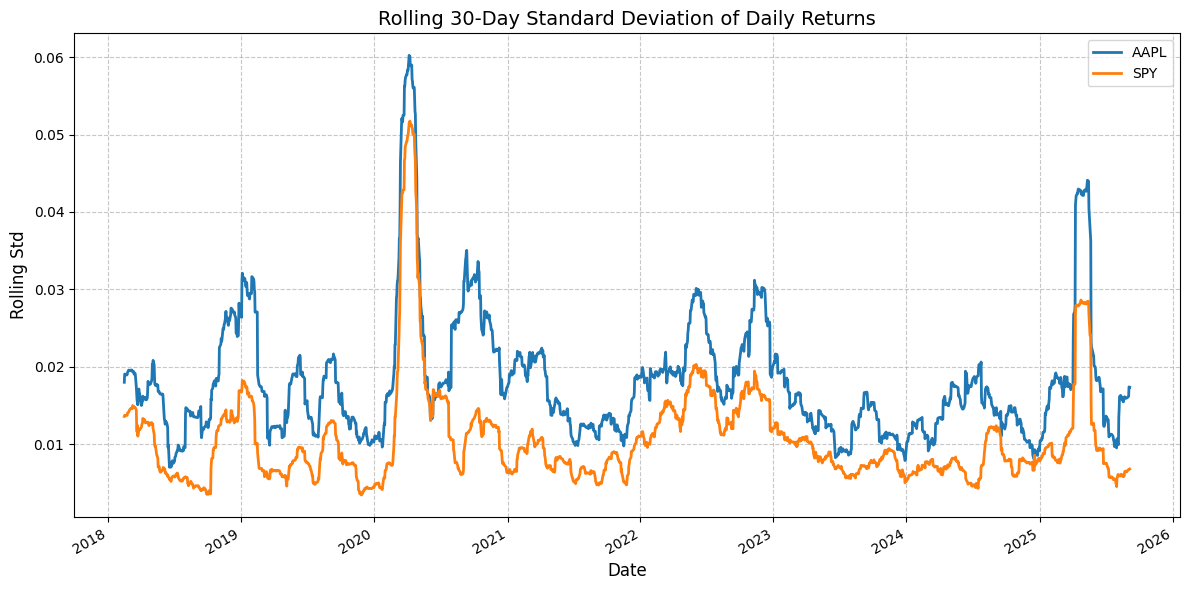

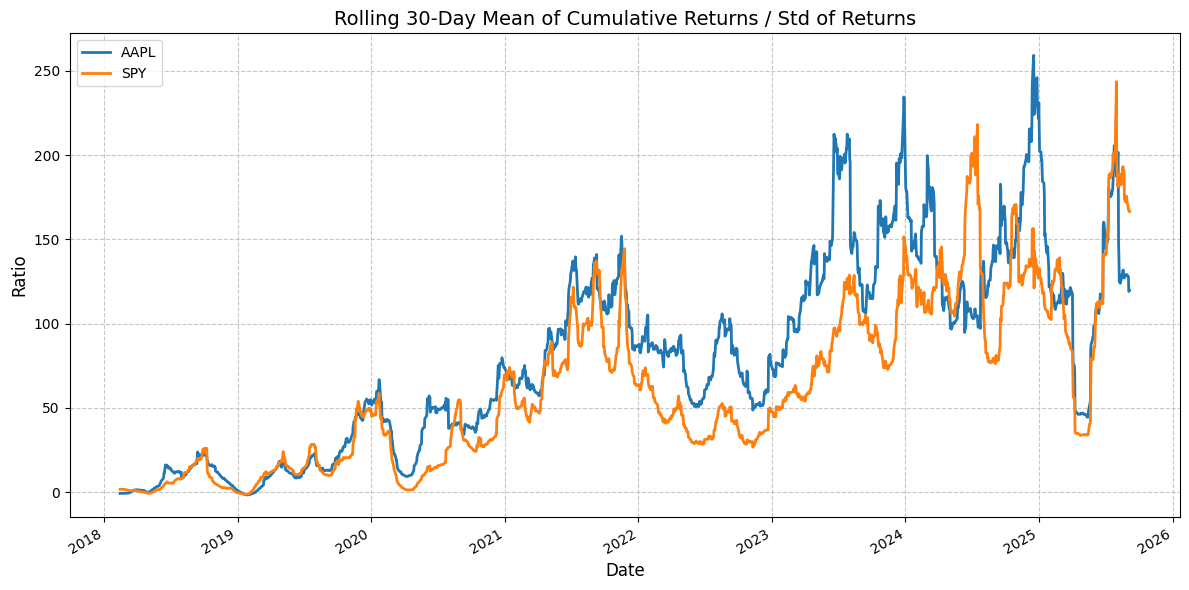

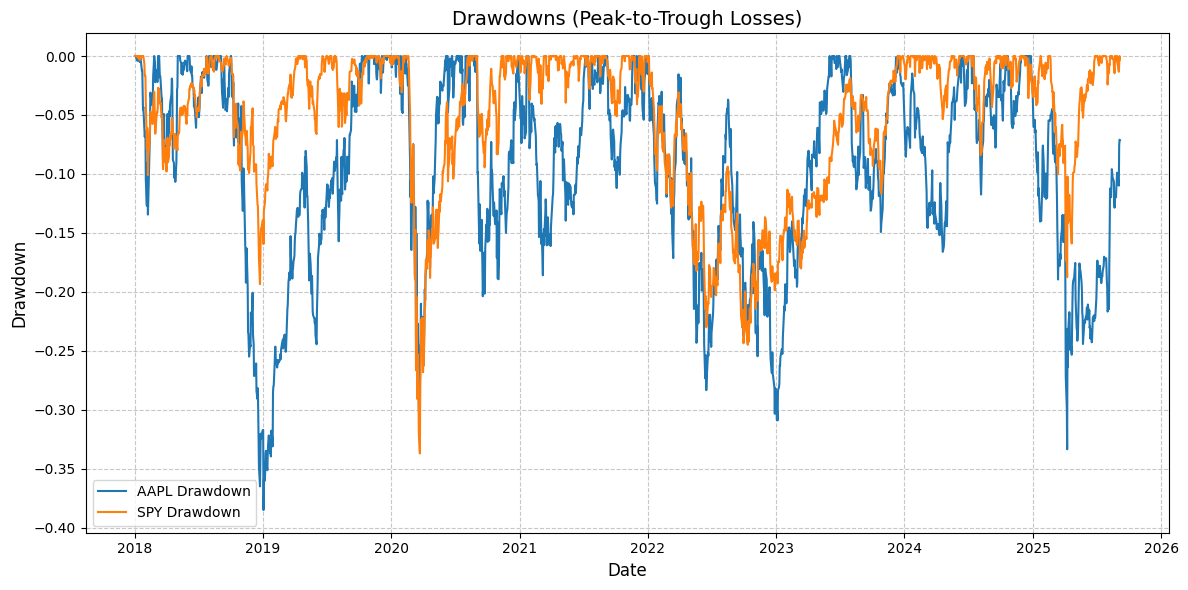

In [ ]:
# Additional price analysis with different visualizations
Analyze_price_2(tickers_interested, df_data_raw)

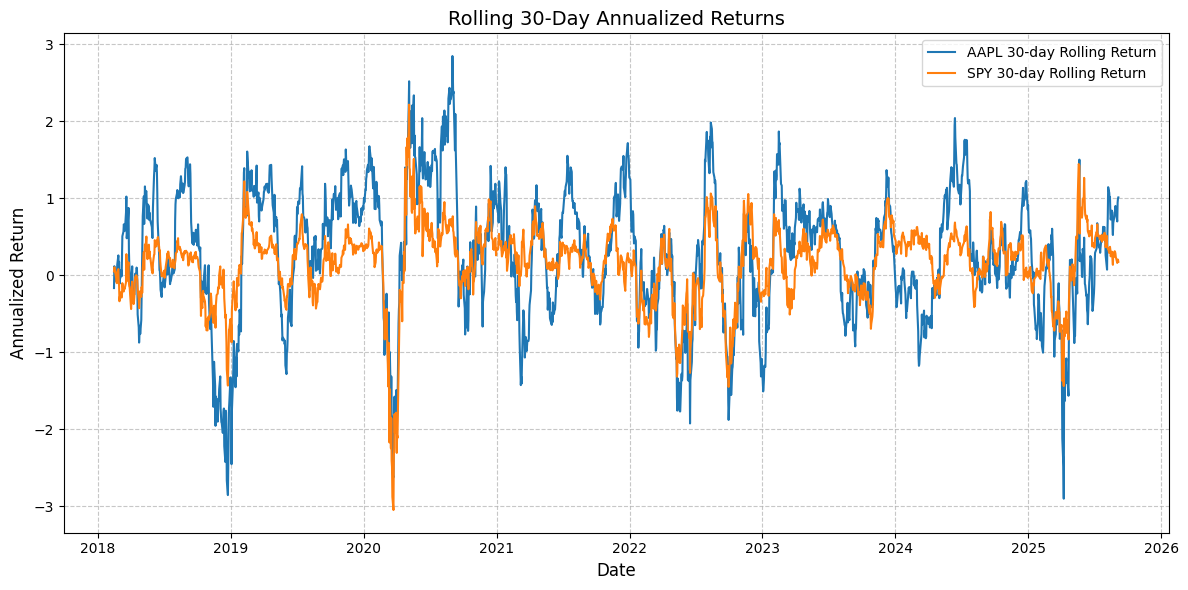

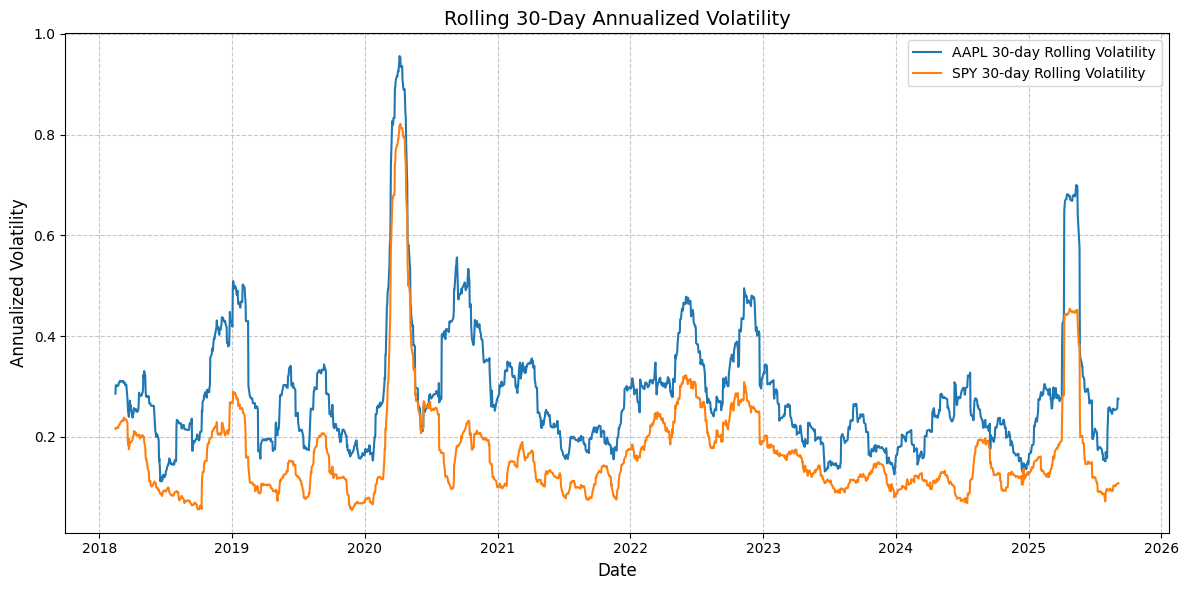

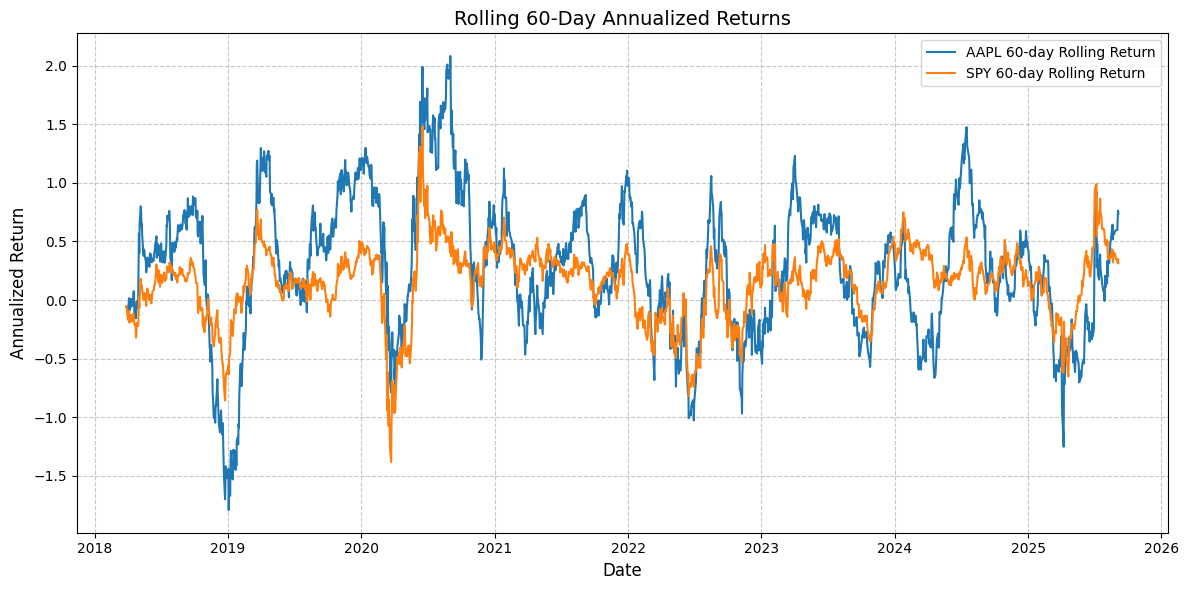

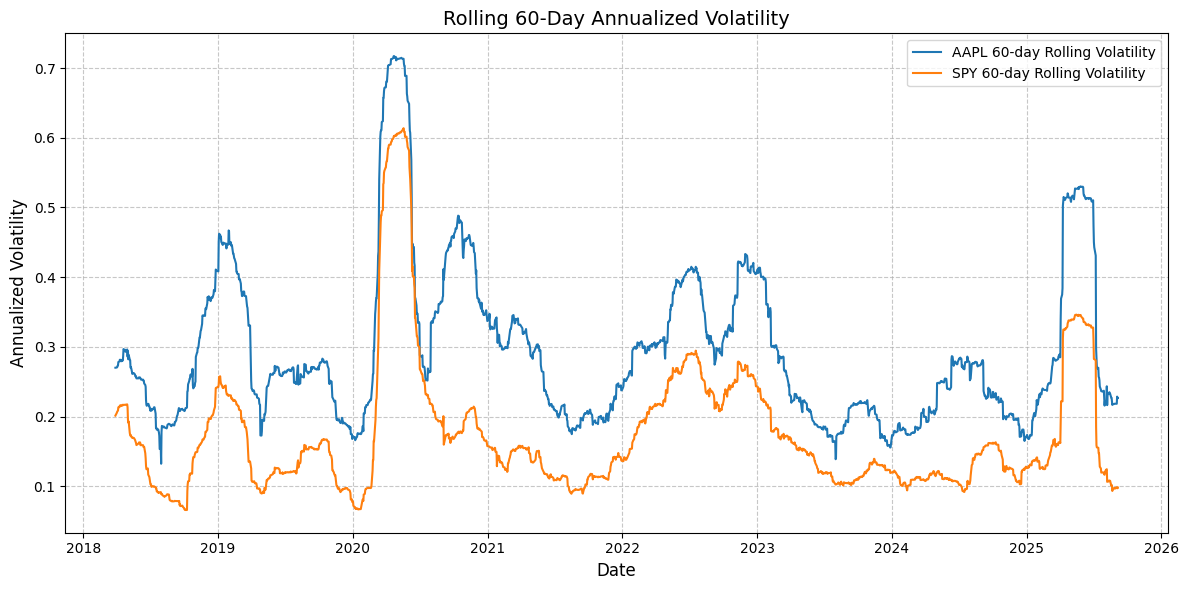

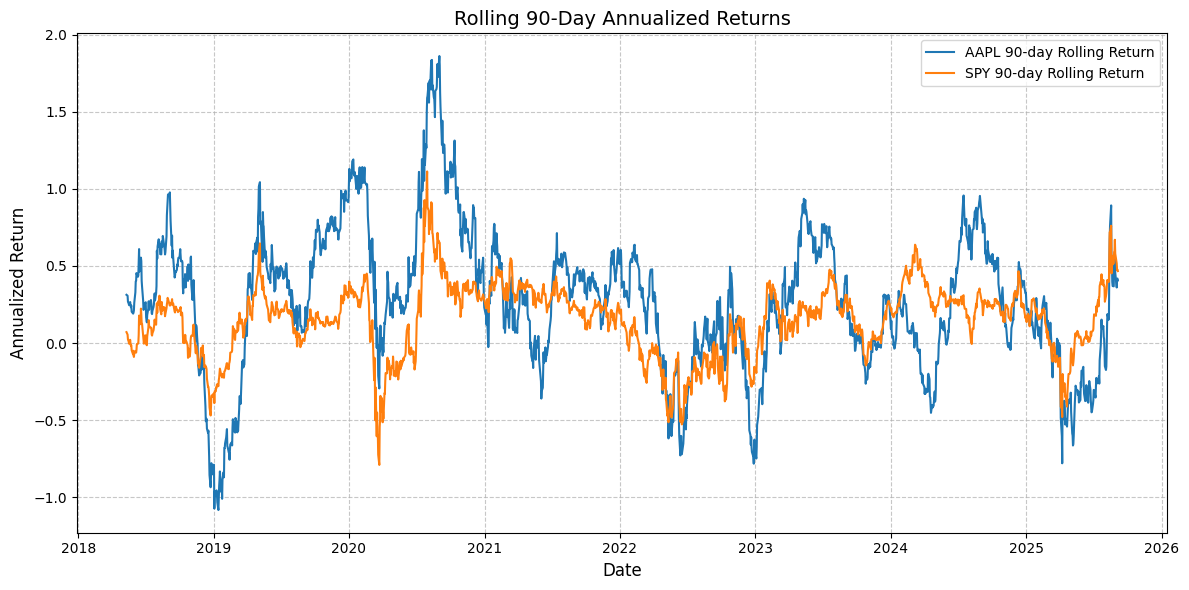

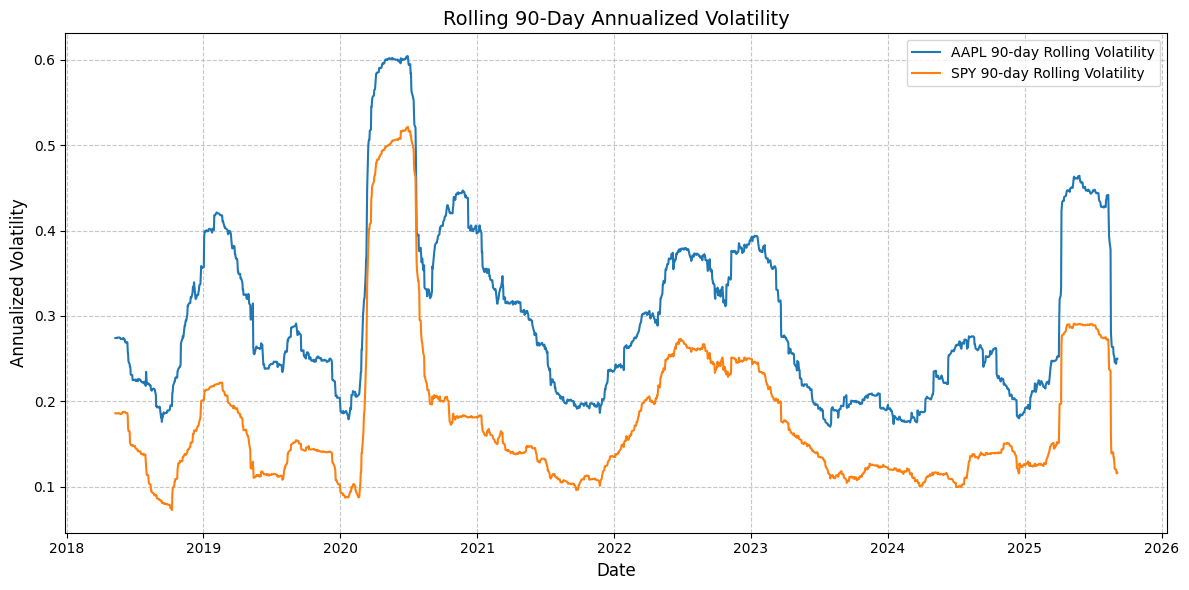


Skewness & Kurtosis of Daily Returns:
        Skewness   Kurtosis
Ticker                     
AAPL    0.152735   6.330530
SPY    -0.288486  12.857745
^GSPC  -0.347408  13.714742


In [ ]:
# Analyze return dynamics: skewness and kurtosis
# - Skewness: Measures asymmetry of return distribution
# - Kurtosis: Measures tail heaviness (fat tails indicate extreme events)
Analyze_price_return_dynamics(tickers_interested, df_data_raw)

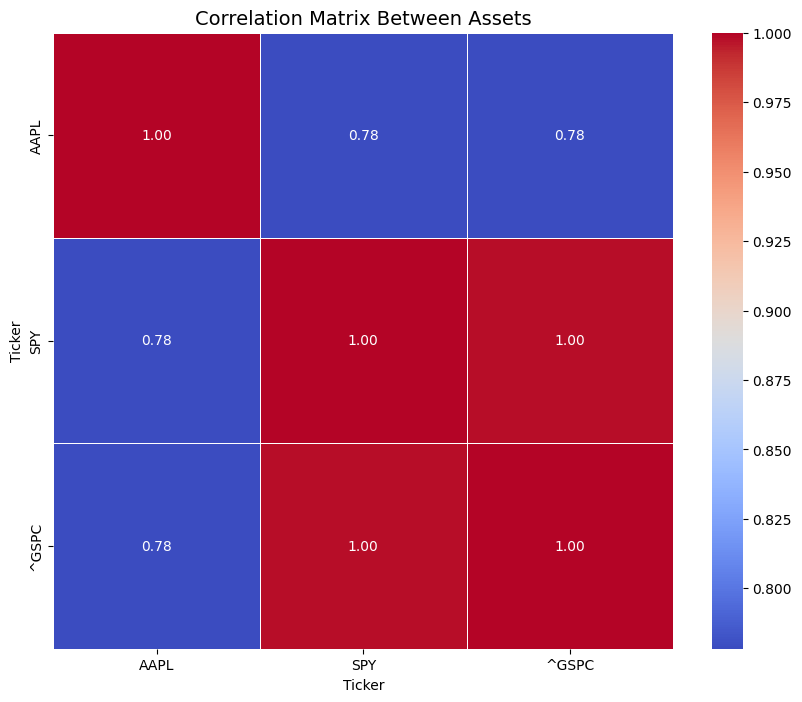

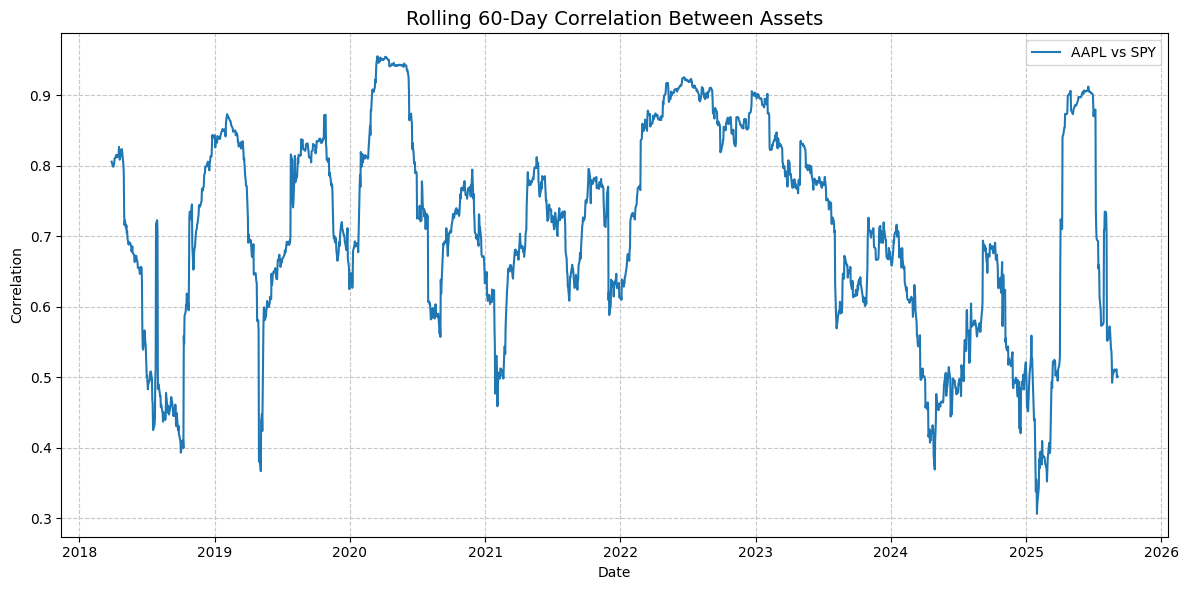


Cointegration Test p-values (pairs with p < 0.05 are significant):
             p-value
AAPL & SPY  0.409471


In [ ]:
# Analyze relationships between assets using cointegration tests
# Cointegration tests whether two time series move together in the long run
# Useful for pairs trading strategies
Analyze_asset_relationships(tickers_interested, df_data_raw)

In [ ]:
### Volume & Liquidity Analysis

Examine trading volume patterns and liquidity characteristics.

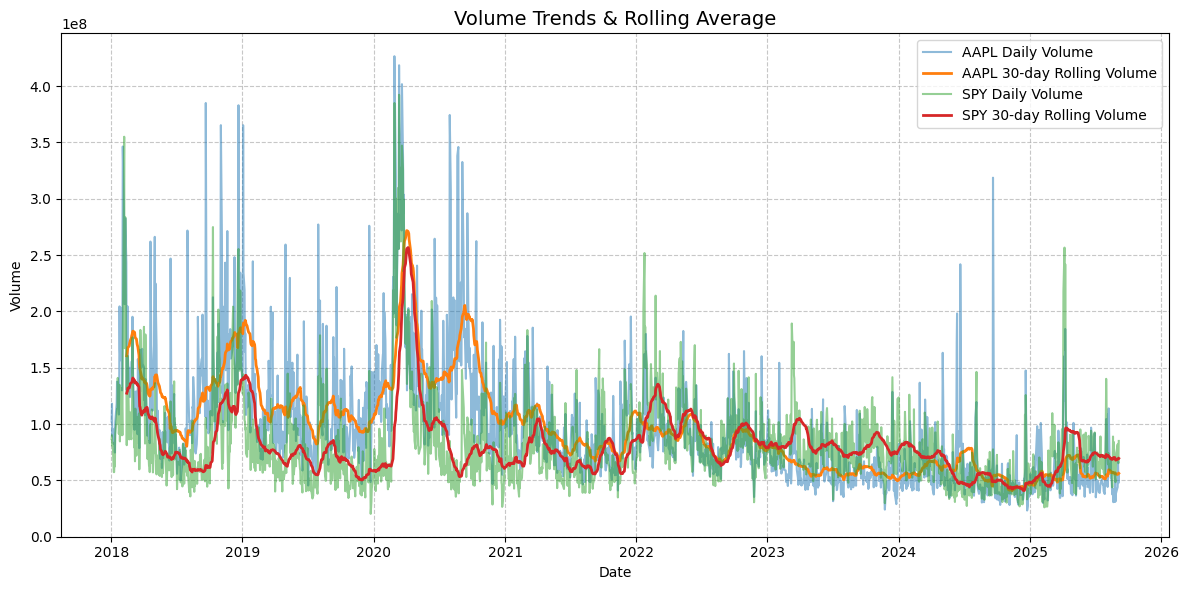

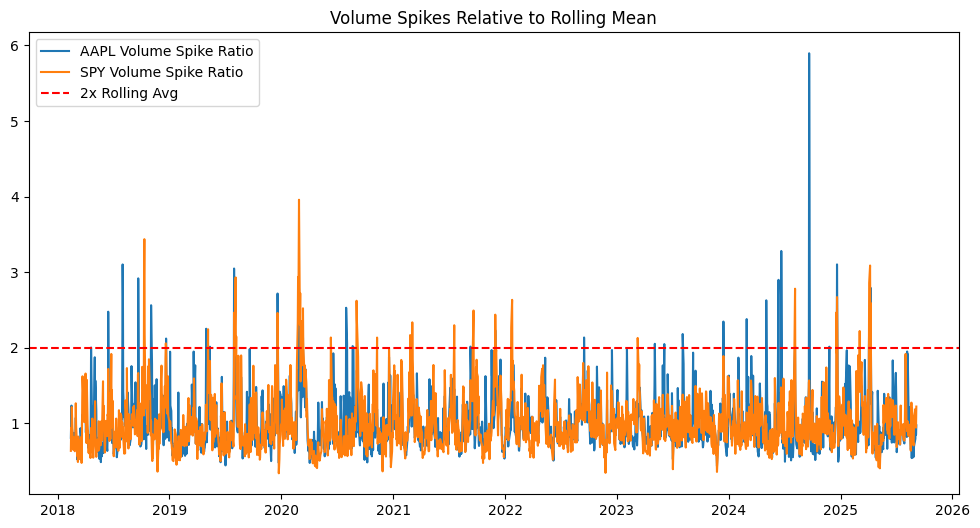

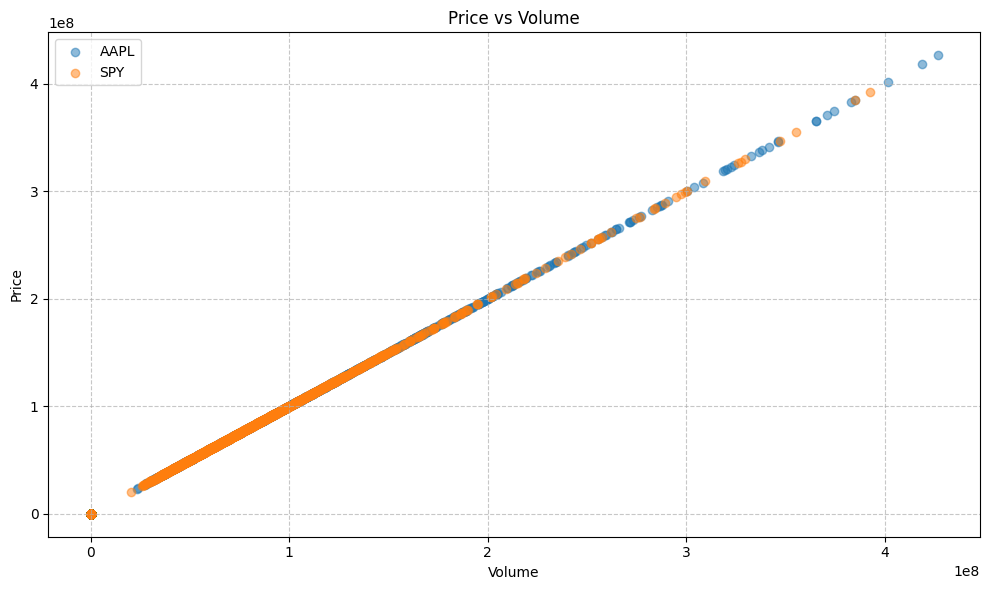

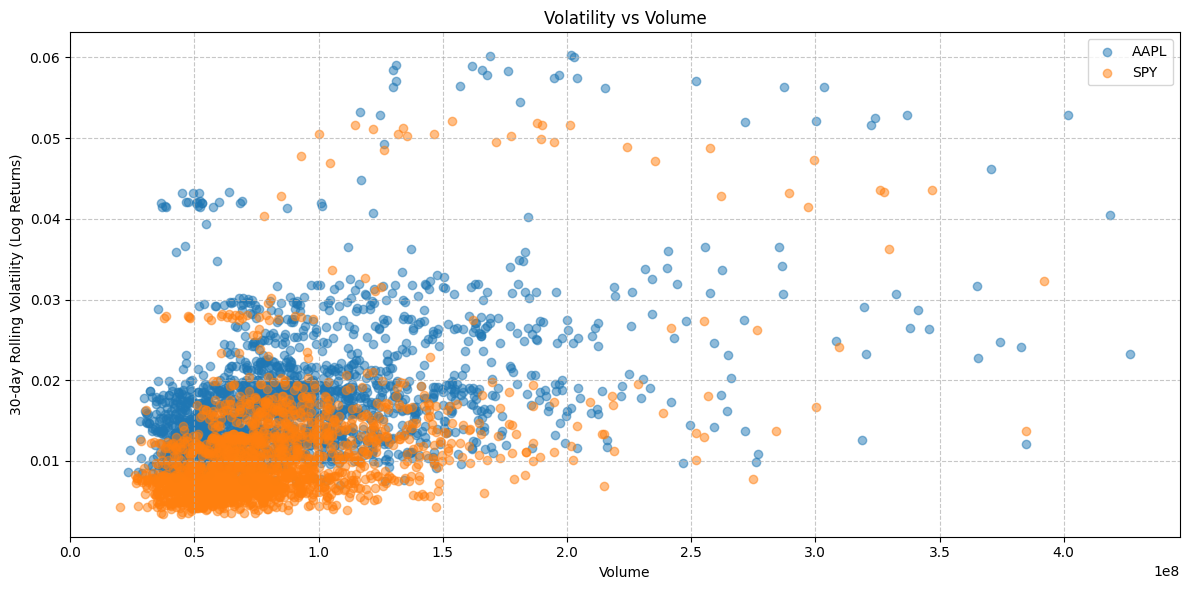

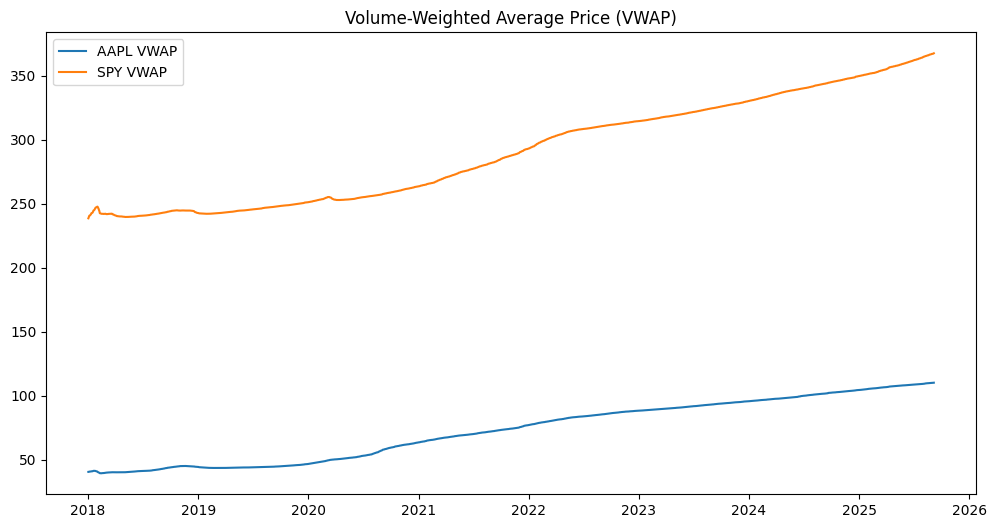

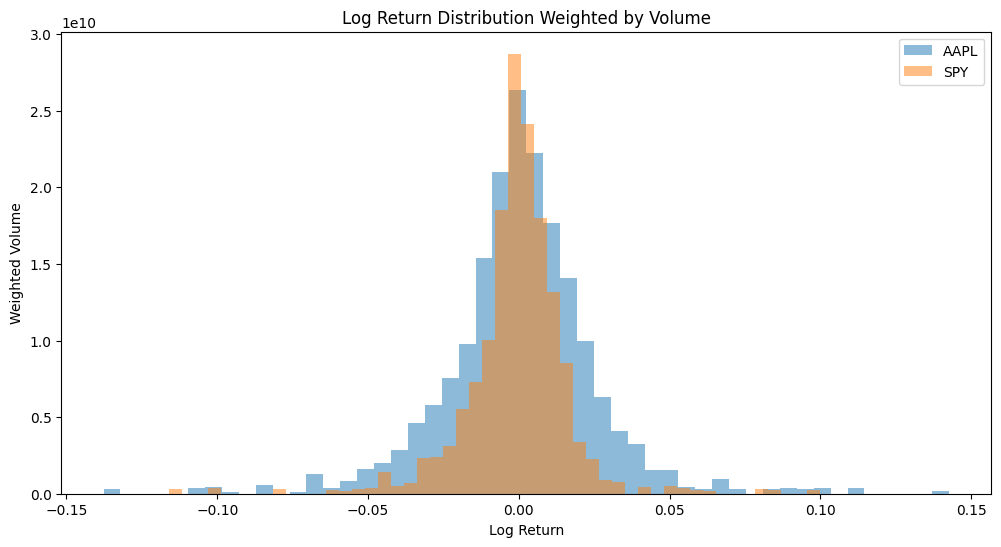

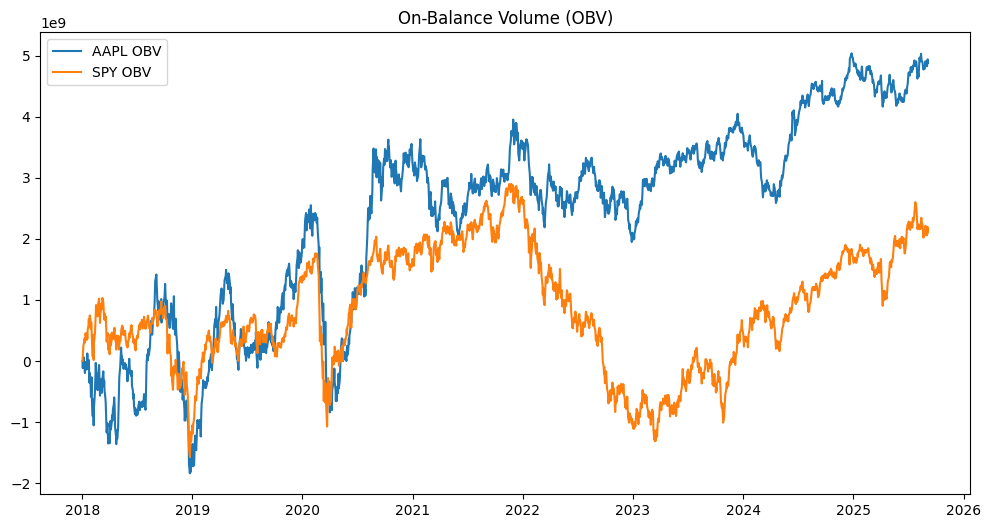

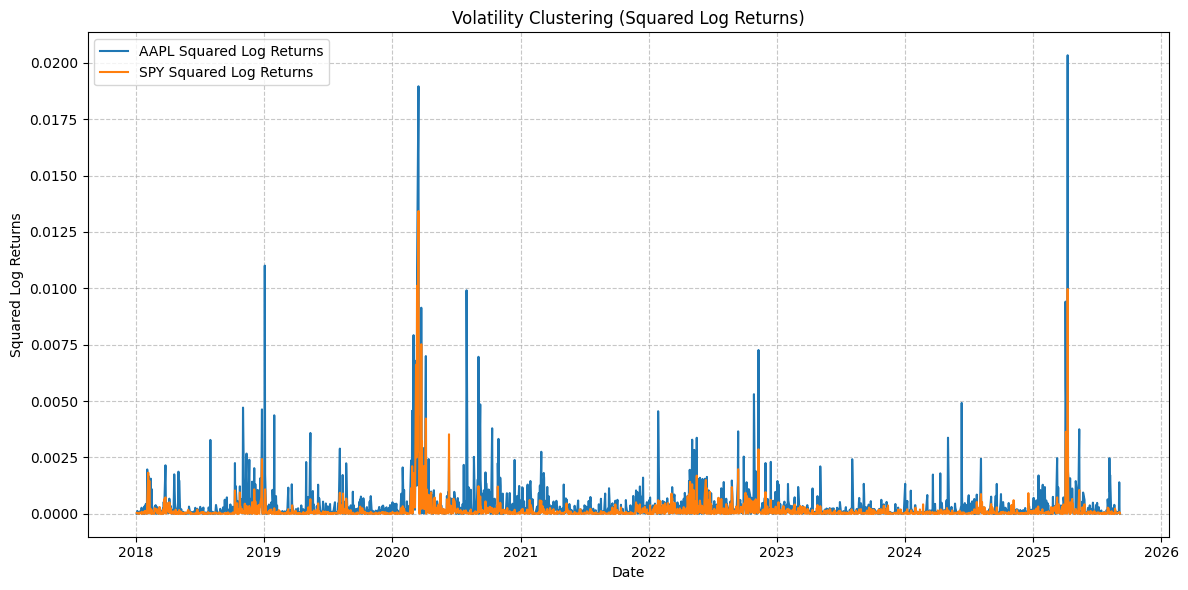

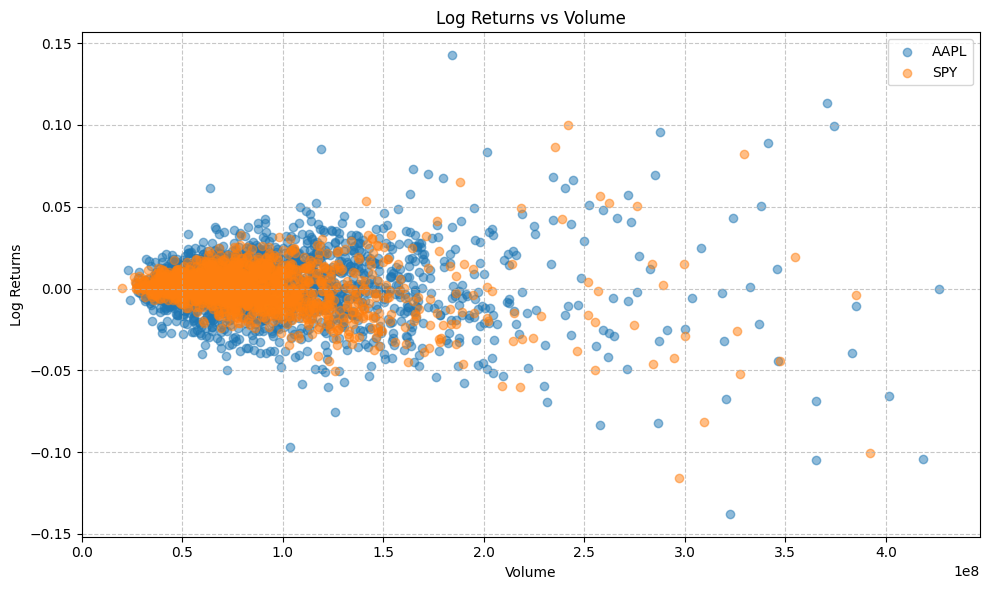

In [ ]:
# Analyze volume, liquidity, and stylized facts of financial returns
# Stylized facts include: volatility clustering, fat tails, leverage effects
Analyze_volume_liquidity_and_stylized_facts(tickers_interested, df_data_raw)

### Impact Analysis: Extreme Days

> **Research Question**: What would happen if we exclude the 10% worst or best trading days?  
> This analysis helps understand the impact of extreme market events on overall returns.

---

## 04.00 | Feature Engineering

Extract technical indicators and statistical features from price and volume data. These features will be used to identify market regimes through clustering.

### Technical Indicators

We'll compute various technical analysis indicators including:
- **Moving Averages**: EMA, SMA (exponential and simple moving averages)
- **Momentum Indicators**: RSI, MACD, Stochastic, Williams %R
- **Volatility Indicators**: Bollinger Bands
- **Volume Indicators**: Money Flow Index (MFI)
- **Statistical Features**: Lagged returns, rolling statistics, percentiles

In [ ]:
# Preview the raw data structure (first 3 rows)
df_data_raw.head(3)

Price       Adj Close                               Close              \
Ticker           AAPL         SPY        ^GSPC       AAPL         SPY   
Date                                                                    
2018-01-02  40.381001  238.568695  2695.810059  43.064999  268.769989   
2018-01-03  40.373966  240.077713  2713.060059  43.057499  270.470001   
2018-01-04  40.561489  241.089554  2723.989990  43.257500  271.609985   

Price                         High                                 Low  \
Ticker            ^GSPC       AAPL         SPY        ^GSPC       AAPL   
Date                                                                     
2018-01-02  2695.810059  43.075001  268.809998  2695.889893  42.314999   
2018-01-03  2713.060059  43.637501  270.640015  2714.370117  42.990002   
2018-01-04  2723.989990  43.367500  272.160004  2729.290039  43.020000   

Price                                     Open                           \
Ticker             SPY        ^GSPC       AAPL         SPY        ^GSPC   
Date                                                                      
2018-01-02  267.399994  2682.360107  42.540001  267.839996  2683.729980   
2018-01-03  268.959991  2697.770020  43.132500  268.959991  2697.850098   
2018-01-04  270.540009  2719.070068  43.134998  271.200012  2719.310059   

Price          Volume                        
Ticker           AAPL       SPY       ^GSPC  
Date                                         
2018-01-02  102223600  86655700  3397430000  
2018-01-03  118071600  90070400  3544030000  
2018-01-04   89738400  80636400  3697340000

In [ ]:
# Preview the raw data structure (last 3 rows)
df_data_raw.tail(3)

Price        Adj Close                                Close              \
Ticker            AAPL         SPY        ^GSPC        AAPL         SPY   
Date                                                                      
2025-09-03  238.470001  643.739990  6448.259766  238.470001  643.739990   
2025-09-04  239.779999  649.119995  6502.080078  239.779999  649.119995   
2025-09-05  239.690002  647.239990  6481.500000  239.690002  647.239990   

Price                          High                                  Low  \
Ticker            ^GSPC        AAPL         SPY        ^GSPC        AAPL   
Date                                                                       
2025-09-03  6448.259766  238.850006  644.210022  6453.669922  234.360001   
2025-09-04  6502.080078  239.899994  649.150024  6502.540039  236.740005   
2025-09-05  6481.500000  241.320007  652.210022  6532.649902  238.490005   

Price                                      Open                           \
Ticker             SPY        ^GSPC        AAPL         SPY        ^GSPC   
Date                                                                       
2025-09-03  640.460022  6416.169922  237.210007  642.669983  6445.819824   
2025-09-04  643.510010  6445.979980  238.449997  644.419983  6456.600098   
2025-09-05  643.330017  6443.979980  240.000000  651.479980  6529.080078   

Price         Volume                        
Ticker          AAPL       SPY       ^GSPC  
Date                                        
2025-09-03  66427800  70820900  4465360000  
2025-09-04  47549400  65219200  4670770000  
2025-09-05  54837300  84970600  5066120000

In [ ]:
# ============================================================================
# Feature Engineering Pipeline
# ============================================================================

# Initialize feature engineer with extended historical data
# Extended data is needed for computing indicators with long lookback periods
fe = FeatureEngineerTA(df_data_raw_long, ["AAPL", "SPY"])

# Build comprehensive feature set using method chaining
features = (fe
    # Moving average log distances
    # Measures distance of price from moving averages (normalized by log)
    .add_EMA_log_dist([10, 20, 40, 60])  # Exponential Moving Averages
    .add_SMA_log_dist([10, 20, 40, 60])  # Simple Moving Averages

    # Momentum indicators
    .add_RSI([14, 28, 56])  # Relative Strength Index (overbought/oversold)
    .add_MACD_log_dist([
        (12, 26, 9),   # Standard MACD
        (5, 35, 5),    # Fast MACD
        (50, 80, 5),   # Slow MACD
        (8, 21, 5)     # Alternative MACD
    ])
    .add_STOCH([
        (14, 3, 3),    # Standard Stochastic
        (21, 5, 5)     # Smoothed Stochastic
    ])
    .add_WILLR(14)     # Williams %R (momentum oscillator)
    .add_WILLR(20)     # Williams %R with longer period

    # Lagged returns and rolling statistics
    # Captures short-term momentum and mean reversion patterns
    .add_lagged_features_returns(
        log_returns_lags=[1, 2, 3, 5],           # Lagged returns
        rolling_windows=[3, 7, 14, 21],          # Rolling statistics
        cumdiff_windows=[3, 5, 7, 9, 15, 40]     # Cumulative differences
    )
    .add_rolling_percentile(window=120, ma_window=10)  # Price percentile over 120 days

    # Volatility indicators
    .add_BBANDS(n=20, nbdevup=2, nbdevdn=2)  # Bollinger Bands (volatility bands)

    # Volume-based indicators
    .add_MFI(14)  # Money Flow Index (14-day)
    .add_MFI(28)  # Money Flow Index (28-day)
)

# Extract the final feature DataFrame
features = fe.get_features()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(uf

In [ ]:
### Alternative Feature Set (Commented Out)

> **Note**: This is a simpler feature set that was used previously.  
> The current implementation uses a more comprehensive feature set above.

```python
# Simplified feature engineering (alternative approach)
# Uncomment to use this instead of the comprehensive feature set above

# fe = FeatureEngineerTA(df_data_raw_long, ["AAPL", "SPY"])
# 
# features = (
#     fe
#     # Moving averages (log distance)
#     .add_EMA_log_dist([10, 20, 40])
#     .add_SMA_log_dist([10, 20, 40])
# 
#     # Momentum indicators
#     .add_RSI([14])
#     .add_STOCH([(14, 3, 3)])
#     .add_WILLR(14)
# 
#     # Lagged returns and statistics
#     .add_lagged_features_returns(log_returns_lags=[1, 2, 3], rolling_windows=[3, 7, 14])
#     .add_rolling_percentile(window=60, ma_window=10)
# )
# 
# df_features = fe.get_features()
```


In [ ]:
# Preview the engineered features (first 3 rows)
# Note: Early rows may contain NaN values due to indicator lookback periods
df_features.head(3)

Ticker                      AAPL                                   \
Feature    Adj Close_pctMA_60_10 Adj Close_pct_60 EMA_log_dist_10   
Date                                                                
2010-01-04                   NaN              NaN             NaN   
2010-01-05                   NaN              NaN             NaN   
2010-01-06                   NaN              NaN             NaN   

Ticker                                                             \
Feature    EMA_log_dist_20 EMA_log_dist_40 RSI_14 SMA_log_dist_10   
Date                                                                
2010-01-04             NaN             NaN    NaN             NaN   
2010-01-05             NaN             NaN    NaN             NaN   
2010-01-06             NaN             NaN    NaN             NaN   

Ticker                                                         ...        SPY  \
Feature    SMA_log_dist_20 SMA_log_dist_40 STOCH_slowd_14_3_3  ... pos_streak   
Date                                                           ...              
2010-01-04             NaN             NaN                NaN  ...          0   
2010-01-05             NaN             NaN                NaN  ...          1   
2010-01-06             NaN             NaN                NaN  ...          2   

Ticker                                                               \
Feature    ret_mean_14 ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_3   
Date                                                                  
2010-01-04         NaN        NaN        NaN         NaN        NaN   
2010-01-05         NaN        NaN        NaN         NaN        NaN   
2010-01-06         NaN        NaN        NaN         NaN        NaN   

Ticker                                                
Feature    ret_skew_7 ret_std_14 ret_std_3 ret_std_7  
Date                                                  
2010-01-04        NaN        NaN       NaN       NaN  
2010-01-05        NaN        NaN       NaN       NaN  
2010-01-06        NaN        NaN       NaN       NaN  

[3 rows x 52 columns]

In [ ]:
df_features.tail(3)

Ticker                      AAPL                                   \
Feature    Adj Close_pctMA_60_10 Adj Close_pct_60 EMA_log_dist_10   
Date                                                                
2025-09-03              0.903390         1.000000        0.031751   
2025-09-04              0.916949         1.000000        0.030356   
2025-09-05              0.930508         0.983051        0.024462   

Ticker                                                                 \
Feature    EMA_log_dist_20 EMA_log_dist_40     RSI_14 SMA_log_dist_10   
Date                                                                    
2025-09-03        0.047979        0.074038  70.085727        0.036808   
2025-09-04        0.048241        0.075487  71.205556        0.036313   
2025-09-05        0.043207        0.071314  71.008892        0.029562   

Ticker                                                         ...        SPY  \
Feature    SMA_log_dist_20 SMA_log_dist_40 STOCH_slowd_14_3_3  ... pos_streak   
Date                                                           ...              
2025-09-03        0.041312        0.083498          72.120014  ...          1   
2025-09-04        0.040958        0.085691          75.135910  ...          2   
2025-09-05        0.036267        0.082194          84.459635  ...          0   

Ticker                                                               \
Feature    ret_mean_14 ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_3   
Date                                                                  
2025-09-03   -0.000127  -0.002672  -0.000348    1.272112   1.648867   
2025-09-04    0.000460   0.002097   0.001471    0.925372  -1.499099   
2025-09-05    0.000421   0.003609   0.000460    0.932824  -1.255813   

Ticker                                                
Feature    ret_skew_7 ret_std_14 ret_std_3 ret_std_7  
Date                                                  
2025-09-03  -0.362131   0.005983  0.007032  0.005386  
2025-09-04  -0.801819   0.006396  0.008385  0.005910  
2025-09-05  -0.170324   0.006417  0.005823  0.005975  

[3 rows x 52 columns]

---

## 05.00 | Data Preprocessing & Train/Test Split

Prepare the data for modeling by:
- **Shifting features**: Align features with future returns (predict tomorrow's return using today's features)
- **Cropping data**: Remove NaN values introduced by feature engineering lookback periods
- **Splitting data**: Separate into training and testing sets for model evaluation

### Important Notes:
- Features are shifted by 1 period to ensure proper alignment with target returns
- Data is cropped to the analysis period after feature engineering
- Train/test split is performed at the specified date


In [ ]:
# ============================================================================
# Prepare features and target for modeling
# ============================================================================

# Copy features and target data
df_train_test_split = df_features.copy()
df_log_returns_TARGET_split = df_log_returns_TARGET.copy()

# Shift features by 1 period to align with future returns
# This ensures we use today's features to predict tomorrow's returns
print("CHECK SHIFT!!!")
display(df_train_test_split.tail(3))                 # Before shift
df_train_test_split = df_train_test_split.shift(1)   # Shift features forward
display(df_train_test_split.tail(3))                 # After shift

# Crop data to analysis period (removes NaN from feature engineering lookback)
df_train_test_split = Crop_df_by_date(df_train_test_split, start_date=start_date, end_date=end_date)
df_log_returns_TARGET_split = Crop_df_by_date(df_log_returns_TARGET_split, start_date=start_date, end_date=end_date)

# Select features and target for SPY (S&P 500 ETF)
df_train_test_split = df_train_test_split.xs('SPY', axis=1, level=0)  # Extract SPY features
df_log_returns_TARGET_split = df_log_returns_TARGET_split['SPY']      # Extract SPY log returns

# Keep a copy for backtesting
df_log_ret_backtest = df_log_returns_TARGET_split.copy()

CHECK SHIFT!!!


Ticker                      AAPL                                   \
Feature    Adj Close_pctMA_60_10 Adj Close_pct_60 EMA_log_dist_10   
Date                                                                
2025-09-03              0.903390         1.000000        0.031751   
2025-09-04              0.916949         1.000000        0.030356   
2025-09-05              0.930508         0.983051        0.024462   

Ticker                                                                 \
Feature    EMA_log_dist_20 EMA_log_dist_40     RSI_14 SMA_log_dist_10   
Date                                                                    
2025-09-03        0.047979        0.074038  70.085727        0.036808   
2025-09-04        0.048241        0.075487  71.205556        0.036313   
2025-09-05        0.043207        0.071314  71.008892        0.029562   

Ticker                                                         ...        SPY  \
Feature    SMA_log_dist_20 SMA_log_dist_40 STOCH_slowd_14_3_3  ... pos_streak   
Date                                                           ...              
2025-09-03        0.041312        0.083498          72.120014  ...          1   
2025-09-04        0.040958        0.085691          75.135910  ...          2   
2025-09-05        0.036267        0.082194          84.459635  ...          0   

Ticker                                                               \
Feature    ret_mean_14 ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_3   
Date                                                                  
2025-09-03   -0.000127  -0.002672  -0.000348    1.272112   1.648867   
2025-09-04    0.000460   0.002097   0.001471    0.925372  -1.499099   
2025-09-05    0.000421   0.003609   0.000460    0.932824  -1.255813   

Ticker                                                
Feature    ret_skew_7 ret_std_14 ret_std_3 ret_std_7  
Date                                                  
2025-09-03  -0.362131   0.005983  0.007032  0.005386  
2025-09-04  -0.801819   0.006396  0.008385  0.005910  
2025-09-05  -0.170324   0.006417  0.005823  0.005975  

[3 rows x 52 columns]

Ticker                      AAPL                                   \
Feature    Adj Close_pctMA_60_10 Adj Close_pct_60 EMA_log_dist_10   
Date                                                                
2025-09-03              0.896610         0.864407        0.001563   
2025-09-04              0.903390         1.000000        0.031751   
2025-09-05              0.916949         1.000000        0.030356   

Ticker                                                                 \
Feature    EMA_log_dist_20 EMA_log_dist_40     RSI_14 SMA_log_dist_10   
Date                                                                    
2025-09-03        0.015784        0.040604  60.576325        0.002873   
2025-09-04        0.047979        0.074038  70.085727        0.036808   
2025-09-05        0.048241        0.075487  71.205556        0.036313   

Ticker                                                         ...        SPY  \
Feature    SMA_log_dist_20 SMA_log_dist_40 STOCH_slowd_14_3_3  ... pos_streak   
Date                                                           ...              
2025-09-03        0.011779        0.049392          71.379143  ...        0.0   
2025-09-04        0.041312        0.083498          72.120014  ...        1.0   
2025-09-05        0.040958        0.085691          75.135910  ...        2.0   

Ticker                                                               \
Feature    ret_mean_14 ret_mean_3 ret_mean_7 ret_skew_14 ret_skew_3   
Date                                                                  
2025-09-03   -0.000269  -0.003295   0.001057    1.380346   1.616433   
2025-09-04   -0.000127  -0.002672  -0.000348    1.272112   1.648867   
2025-09-05    0.000460   0.002097   0.001471    0.925372  -1.499099   

Ticker                                                
Feature    ret_skew_7 ret_std_14 ret_std_3 ret_std_7  
Date                                                  
2025-09-03   0.854953   0.005864  0.005960  0.007854  
2025-09-04  -0.362131   0.005983  0.007032  0.005386  
2025-09-05  -0.801819   0.006396  0.008385  0.005910  

[3 rows x 52 columns]

In [ ]:
# Verify data type (should be pandas DataFrame)
print(type(df_train_test_split))

<class 'pandas.core.frame.DataFrame'>


### Perform Train/Test Split

Split the data at the specified date to create training and testing sets.

In [ ]:
# Split features and targets into train and test sets
# Training: data before split_date
# Testing: data from split_date onwards
df_x_train, df_x_test = Train_test_split(df_train_test_split, split_date)
df_y_train, df_y_test = Train_test_split(df_log_returns_TARGET_split, split_date)

# Split backtest returns for performance evaluation
df_log_ret_train_backtest, df_log_ret_test_backtest = Train_test_split(df_log_ret_backtest, split_date)

In [ ]:
# Preview the target log returns
df_log_returns_TARGET_split.head()

,SPY
Date,
2018-01-02,0.007132
2018-01-03,0.006306
2018-01-04,0.004206
2018-01-05,0.006642
2018-01-08,0.001827


In [ ]:
# Preview training features (first 3 rows)
df_x_train.head(3)

Feature,Adj Close_pctMA_60_10,Adj Close_pct_60,EMA_log_dist_10,EMA_log_dist_20,EMA_log_dist_40,RSI_14,SMA_log_dist_10,SMA_log_dist_20,SMA_log_dist_40,STOCH_slowd_14_3_3,...,pos_streak,ret_mean_14,ret_mean_3,ret_mean_7,ret_skew_14,ret_skew_3,ret_skew_7,ret_std_14,ret_std_3,ret_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.964407,0.864407,0.000125,0.005763,0.017166,63.908915,-0.001737,0.005133,0.019274,-521.533704,...,0.0,0.000726,-0.000412,-0.000166,0.601093,-1.220915,-0.733929,0.003614,0.003019,0.002023
2018-01-03,0.964407,1.000000,0.005934,0.011659,0.023099,69.971100,0.004549,0.011201,0.025213,-625.020564,...,1.0,0.001021,0.001803,0.000928,0.555749,-0.207445,0.749516,0.003966,0.005459,0.003399
2018-01-04,0.964407,1.000000,0.010003,0.016240,0.027950,74.135560,0.010007,0.016064,0.030248,-702.035917,...,2.0,0.001345,0.003220,0.001535,0.371438,-1.696066,0.399543,0.004209,0.006074,0.003966


In [ ]:
# Preview training features (last 3 rows)
df_x_train.tail(3)

Feature,Adj Close_pctMA_60_10,Adj Close_pct_60,EMA_log_dist_10,EMA_log_dist_20,EMA_log_dist_40,RSI_14,SMA_log_dist_10,SMA_log_dist_20,SMA_log_dist_40,STOCH_slowd_14_3_3,...,pos_streak,ret_mean_14,ret_mean_3,ret_mean_7,ret_skew_14,ret_skew_3,ret_skew_7,ret_std_14,ret_std_3,ret_std_7
Date,,,,,,,,,,,,,,,,,,,,,
2023-12-27,0.986441,1.0,0.011995,0.024865,0.044355,72.995151,0.010391,0.026699,0.052941,43.964094,...,3.0,0.003209,0.005220,0.001675,-1.284380,1.103913,-1.640868,0.006555,0.003816,0.007712
2023-12-28,0.986441,1.0,0.011278,0.024100,0.043860,73.673074,0.009168,0.025981,0.051285,47.653227,...,4.0,0.003626,0.002676,0.002169,-1.586380,1.687928,-1.987173,0.006236,0.001335,0.007573
2023-12-29,0.986441,1.0,0.009526,0.022121,0.042033,73.821228,0.007834,0.023786,0.048345,52.825525,...,5.0,0.003110,0.002133,0.001422,-1.373584,0.735618,-1.703429,0.006180,0.001939,0.007434


---

## 06.00 | Feature Transformation with PCA

Apply dimensionality reduction using Principal Component Analysis (PCA) to:
- **Reduce noise**: Focus on the most important feature variations
- **Improve clustering**: Work with uncorrelated principal components
- **Handle multicollinearity**: Remove redundant information from technical indicators

### Steps:
1. **Scaling**: Normalize features (MinMax scaling)
2. **PCA Fitting**: Determine optimal number of components
3. **Transformation**: Project features onto principal components

In [ ]:
# Initialize feature transformer with train and test data
ft = FeatureTransformer(df_x_train, df_x_test)

# Scale features using MinMax scaling (normalizes to [0, 1] range)
# This ensures all features are on the same scale for PCA
ft.scale("minmax")

# Get scaled data
train_scaled, test_scaled = ft.get_scaled_data()

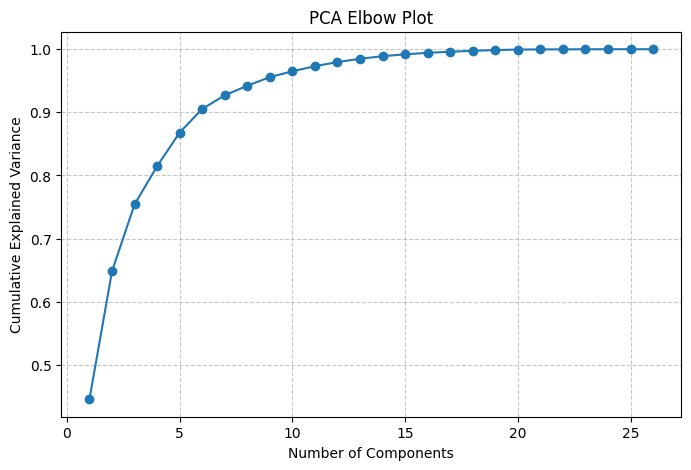

In [ ]:
# Handle missing values (fill with zeros)
ft.fillna_zero()

# Fit PCA on training data
ft.fit_pca()

# Visualize explained variance to determine optimal number of components
ft.plot_elbow()

In [ ]:
# Transform features to PCA space using top 15 principal components
# These components capture the majority of variance in the original features
train_pca, test_pca = ft.transform(n_features=15)

# Alternative: Use scaled features directly (uncomment to use instead of PCA)
# train_pca = train_scaled
# test_pca = test_scaled

# Preview transformed features
print("\nPCA Train:")
display(train_pca.head())
print("\nPCA Test:")
display(test_pca.head())


PCA Train:


,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15
Date,,,,,,,,,,,,,,,
2018-01-02,0.471349,-0.415075,0.842146,-0.503972,0.537782,0.032602,-0.319326,-0.017523,0.133486,-0.004765,-0.055739,-0.017725,0.039078,-0.011853,-0.062773
2018-01-03,0.630013,-0.075478,0.796259,-0.516442,0.771449,-0.155733,-0.277106,0.024188,-0.027279,-0.018397,-0.055556,-0.067764,0.044318,-0.035843,-0.027884
2018-01-04,0.652876,-0.509939,0.651522,-0.492990,0.724654,-0.177827,-0.208957,0.078287,-0.007250,-0.051812,-0.069040,-0.004188,0.075035,-0.003126,0.023092
2018-01-05,0.661772,-0.381063,0.482580,-0.522394,0.521028,-0.135516,-0.122242,0.110127,0.051176,0.019390,-0.050781,-0.000100,0.083628,0.037243,0.023472
2018-01-08,0.672044,-0.529934,0.272612,-0.496050,0.304319,-0.088571,-0.044249,0.135750,0.127085,-0.011750,-0.057367,-0.029581,0.085180,0.075895,0.035369



PCA Test:


,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15
Date,,,,,,,,,,,,,,,
2024-01-02,0.441037,-0.359543,-0.092877,0.116635,-0.374597,0.131357,-0.014341,-0.028203,-0.014576,-0.014878,0.059729,-0.032906,0.109983,0.081484,0.003245
2024-01-03,0.345458,0.088980,0.002415,0.288779,-0.202666,0.121522,0.051112,0.048052,-0.085037,-0.008301,0.023348,-0.023359,0.065058,0.062055,-0.010008
2024-01-04,0.221428,-0.001042,0.139710,0.242402,-0.285743,0.196712,0.029927,0.076392,0.070608,0.007395,0.020719,0.003315,0.020015,0.013123,-0.011462
2024-01-05,0.148627,-0.038169,0.244272,0.300686,-0.194913,0.222224,0.058733,0.180264,-0.006771,0.013497,0.015715,0.014965,0.027119,0.002207,0.004396
2024-01-08,0.199885,-0.066323,0.094931,0.014852,-0.191069,-0.015154,0.127015,-0.129802,-0.041064,-0.010949,0.009434,0.000588,0.001945,0.021130,-0.038360


---

## 07.00 | Clustering Analysis

Apply multiple clustering algorithms to identify distinct market regimes. Each cluster represents a different market state (e.g., bull market, bear market, high volatility, low volatility).

### Clustering Algorithms Used:
- **K-Means**: Partition-based clustering with specified number of clusters
- **DBSCAN**: Density-based clustering (identifies noise points)
- **OPTICS**: Density-based clustering with variable density clusters
- **Mean Shift**: Mode-seeking algorithm
- **Spectral Clustering**: Graph-based clustering
- **Bayesian Gaussian Mixture**: Probabilistic clustering
- **Affinity Propagation**: Message-passing based clustering
- **Birch**: Hierarchical clustering for large datasets

In [ ]:
# All imports are already done at the beginning of the notebook
# This cell defines the clustering function

In [ ]:
def Cluster_and_score(train_data, test_data, model, model_name, df_estimate_train, df_estimate_test):

    # Fit model
    train_labels = model.fit_predict(train_data)

    # Handle test labels for models without a predict method
    if hasattr(model, 'predict'):
        test_labels = model.predict(test_data)
    else:
        # Use Nearest Neighbors with k=3 for DBSCAN test labeling
        nn = NearestNeighbors(n_neighbors=3).fit(train_data[train_labels != -1])  # fit on non-noise points
        _, indices = nn.kneighbors(test_data)

        # Map nearest neighbors’ labels
        neighbor_labels = train_labels[train_labels != -1][indices]

        # Assign most common label among the 3 nearest neighbors
        test_labels = np.array([np.bincount(row).argmax() for row in neighbor_labels])


    # Add labels
    df_estimate_train[f'Cluster_{model_name}'] = train_labels
    df_estimate_test[f'Cluster_{model_name}'] = test_labels

    return df_estimate_train, df_estimate_test

In [ ]:
# Install scikit-learn-extra for additional clustering algorithms (optional)
# Note: Currently not used, but available for future extensions
# pip install scikit-learn-extra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 11.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=2176924 sha256=051390c7a040f113a074ffbe13ab69ed7f8153d1430fdc16d9610901ecaa32d2
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
# All imports are already done at the beginning of the notebook
# This cell applies multiple clustering algorithms to identify market regimes


In [ ]:
# ============================================================================
# Apply Multiple Clustering Algorithms
# ============================================================================

# Initialize DataFrames to store cluster labels
df_estimate_train = pd.DataFrame()
df_estimate_test = pd.DataFrame()

# Set indices to match PCA-transformed data
df_estimate_train.index = train_pca.index
df_estimate_test.index = test_pca.index

# Define cluster numbers to test for partition-based algorithms
cluster_list = [3, 5, 7, 9, 12]
# Alternative cluster lists (uncomment to use):
# cluster_list = [3, 5, 7, 9, 12, 20, 30, 40, 50, 100]
# cluster_list = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# --------------------
# K-Means Clustering
# --------------------
# Partition-based clustering with specified number of clusters
for n_clusters in cluster_list:
    mod_name = f'KM{n_clusters}'
    model = KMeans(n_clusters=n_clusters, random_state=42)
    df_estimate_train, df_estimate_test = Cluster_and_score(
        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
    )

# --------------------
# Agglomerative Clustering (Commented Out)
# --------------------
# Hierarchical clustering - currently disabled
# for n_clusters in cluster_list:
#     mod_name = f'AGG{n_clusters}'
#     model = AgglomerativeClustering(n_clusters=n_clusters)
#     df_estimate_train, df_estimate_test = Cluster_and_score(
#         train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
#     )

# --------------------
# DBSCAN (Density-Based Clustering)
# --------------------
# Identifies clusters based on density, can identify noise points
mod_name = 'DBSCAN'
model = DBSCAN(eps=0.5, min_samples=5)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)

# --------------------
# OPTICS (Ordering Points To Identify Clustering Structure)
# --------------------
# Density-based clustering that handles variable density clusters
mod_name = 'OPTICS'
model = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.1)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)

# --------------------
# Mean Shift Clustering
# --------------------
# Mode-seeking algorithm that finds clusters based on density modes
mod_name = 'MeanShift'
model = MeanShift()
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)

# --------------------
# Spectral Clustering
# --------------------
# Graph-based clustering using eigenvalues of similarity matrix
for n_clusters in cluster_list:
    mod_name = f'SP{n_clusters}'
    model = SpectralClustering(n_clusters=n_clusters, random_state=42, assign_labels='kmeans')
    df_estimate_train, df_estimate_test = Cluster_and_score(
        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
    )

# --------------------
# Bayesian Gaussian Mixture
# --------------------
# Probabilistic clustering that determines number of components automatically
mod_name = "BayesGMM"
model = BayesianGaussianMixture(n_components=15, random_state=42)  # Upper bound on clusters
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)

# --------------------
# Affinity Propagation
# --------------------
# Message-passing based clustering that determines number of clusters automatically
mod_name = "AffinityProp"
model = AffinityPropagation(random_state=42, preference=-50)
df_estimate_train, df_estimate_test = Cluster_and_score(
    train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
)

# --------------------
# BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)
# --------------------
# Hierarchical clustering optimized for large datasets
for n_clusters in cluster_list:
    mod_name = f'Birch{n_clusters}'
    model = Birch(n_clusters=n_clusters)
    df_estimate_train, df_estimate_test = Cluster_and_score(
        train_pca, test_pca, model, mod_name, df_estimate_train, df_estimate_test
    )


/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


In [ ]:
# Display cluster labels for training data
# Each column represents a different clustering algorithm's results
df_estimate_train

,Cluster_KM3,Cluster_KM5,Cluster_KM7,Cluster_KM9,Cluster_KM12,Cluster_DBSCAN,Cluster_OPTICS,Cluster_MeanShift,Cluster_SP3,Cluster_SP5,Cluster_SP7,Cluster_SP9,Cluster_SP12,Cluster_BayesGMM,Cluster_AffinityProp,Cluster_Birch3,Cluster_Birch5,Cluster_Birch7,Cluster_Birch9,Cluster_Birch12
Date,,,,,,,,,,,,,,,,,,,,
2018-01-02,2,4,4,6,6,0,0,0,0,0,0,6,6,6,1,2,1,4,1,10
2018-01-03,2,4,4,6,6,-1,0,0,0,0,0,3,6,6,0,2,1,4,1,10
2018-01-04,2,4,4,6,6,0,0,0,0,0,0,6,6,6,1,2,1,4,1,10
2018-01-05,2,4,4,6,6,0,0,0,0,0,0,6,6,10,1,2,1,4,1,10
2018-01-08,2,4,4,6,6,0,0,0,0,0,0,6,6,10,1,2,1,4,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,2,4,4,5,5,0,0,0,0,0,0,6,6,2,1,2,1,4,1,2
2023-12-26,2,4,4,5,5,0,0,0,0,0,0,6,6,10,1,2,1,4,1,2
2023-12-27,1,3,3,2,10,0,0,0,0,0,0,3,7,10,0,2,4,0,7,7


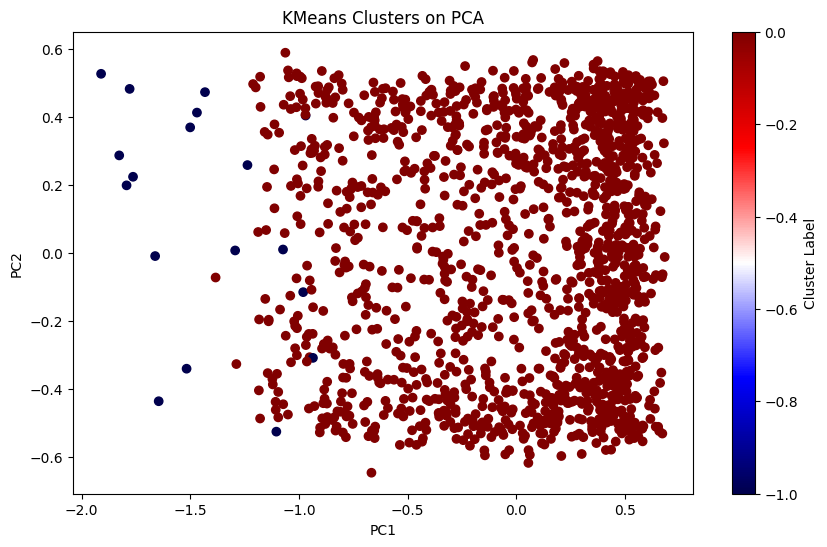

In [ ]:
# Visualize clusters in 2D PCA space
# This shows how different market regimes are separated in feature space
plt.figure(figsize=(10, 6))
plt.scatter(train_pca['PCA_1'], train_pca['PCA_2'], 
            c=df_estimate_train['Cluster_OPTICS'], cmap='seismic')
plt.xlabel("First Principal Component (PC1)")
plt.ylabel("Second Principal Component (PC2)")
plt.title("OPTICS Clusters Visualized in PCA Space")
plt.colorbar(label='Cluster Label')
plt.grid(True, alpha=0.3)
plt.show()

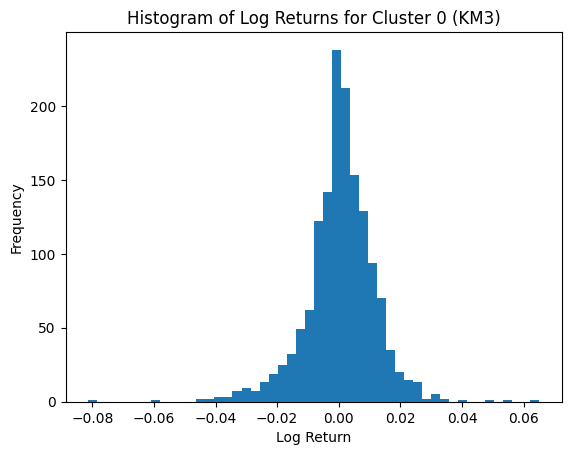

In [ ]:
# Analyze return distribution for a specific cluster
# This helps understand the return characteristics of different market regimes
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values

# Filter for cluster 0 (from OPTICS clustering)
df_clust_hist = df_clust_hist[df_clust_hist['Cluster_OPTICS'] == 0]

# Plot histogram of returns for this cluster
df_clust_hist['Log_ret'].plot.hist(bins=50)
plt.title('Return Distribution for OPTICS Cluster 0')
plt.xlabel('Log Return')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipython-input-960233324.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


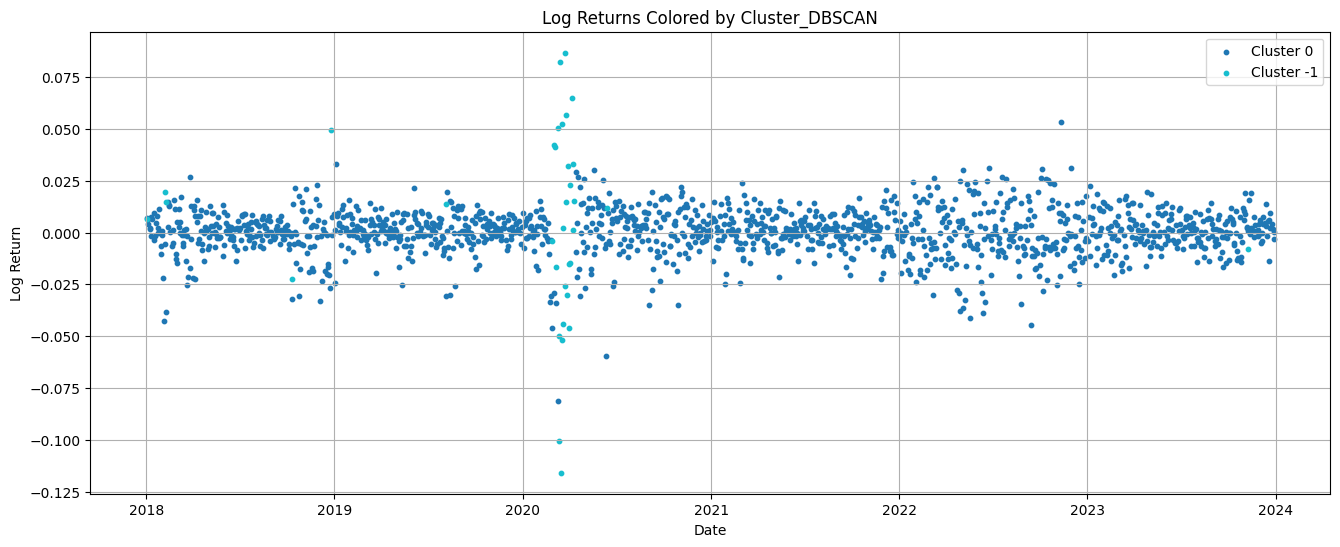

In [ ]:
# Visualize log returns over time, colored by cluster assignment
# This shows how different market regimes correspond to different return patterns
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_train.columns if 'Cluster' in col]

# Choose cluster labeling to visualize (index 5 corresponds to one of the clustering methods)
cluster_label_col = cluster_cols[5]  # Can be changed to any cluster column
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors using modern matplotlib API
colors = plt.colormaps['tab10'](np.linspace(0, 1, len(clusters)))

# Plot returns for each cluster
for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], 
                color=colors[i], label=f'Cluster {cluster}', s=10, alpha=0.6)

plt.title(f'Log Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2435446943.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


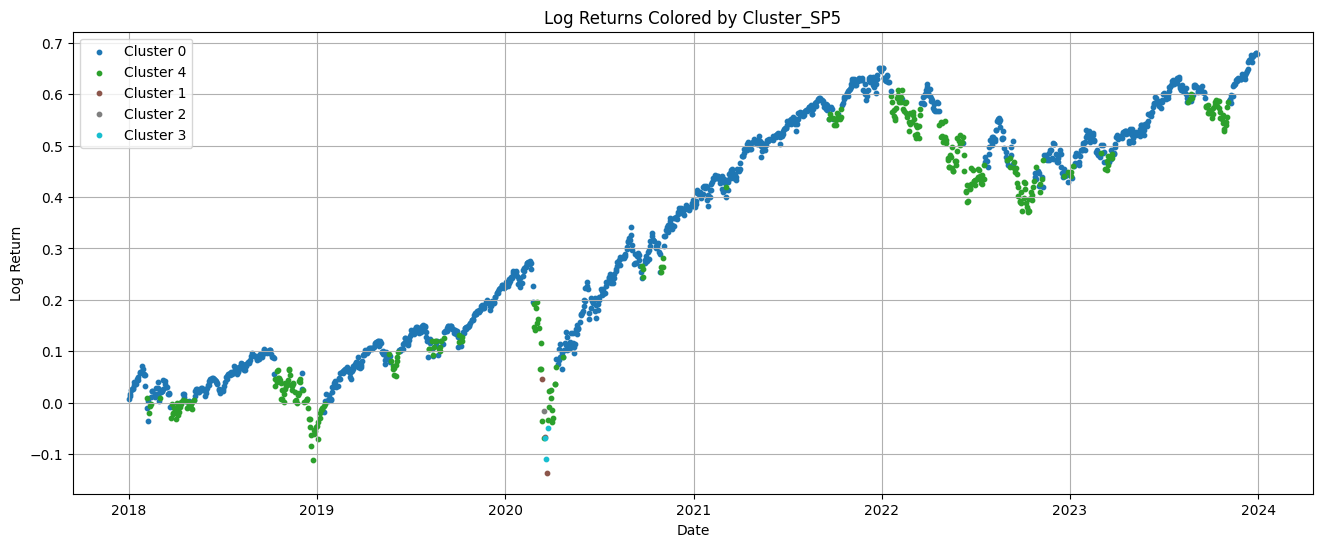

In [ ]:
# Visualize cumulative returns over time, colored by cluster assignment
# Cumulative returns show the equity curve evolution for different market regimes
df_clust_hist = df_estimate_train.copy()
df_clust_hist['Log_ret'] = df_log_ret_train_backtest.values
df_clust_hist['Log_ret'] = df_clust_hist['Log_ret'].cumsum()  # Cumulative sum

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_train.columns if 'Cluster' in col]

# Choose cluster labeling to visualize
cluster_label_col = cluster_cols[9]  # Can be changed to any cluster column
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors using modern matplotlib API
colors = plt.colormaps['tab10'](np.linspace(0, 1, len(clusters)))

# Plot cumulative returns for each cluster
for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], 
                color=colors[i], label=f'Cluster {cluster}', s=10, alpha=0.6)

plt.title(f'Cumulative Returns (Equity Curve) Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2710050432.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(clusters))


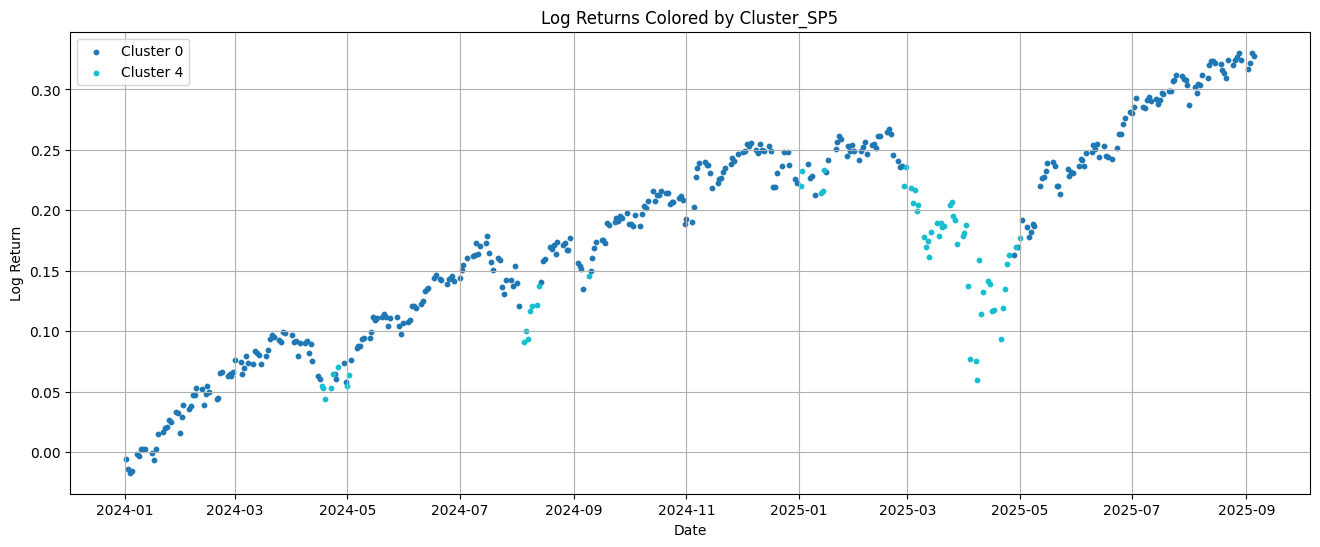

In [ ]:
# Visualize cumulative returns on TEST data, colored by cluster assignment
# This shows how clusters identified in training perform on unseen data
df_clust_hist = df_estimate_test.copy()
df_clust_hist['Log_ret'] = df_log_ret_test_backtest.values
df_clust_hist['Log_ret'] = df_clust_hist['Log_ret'].cumsum()  # Cumulative sum

plt.figure(figsize=(16, 6))

# Select cluster columns
cluster_cols = [col for col in df_estimate_test.columns if 'Cluster' in col]

# Choose cluster labeling to visualize
cluster_label_col = cluster_cols[9]  # Can be changed to any cluster column
clusters = df_clust_hist[cluster_label_col].unique()

# Map clusters to colors using modern matplotlib API
colors = plt.colormaps['tab10'](np.linspace(0, 1, len(clusters)))

# Plot cumulative returns for each cluster
for i, cluster in enumerate(clusters):
    cluster_data = df_clust_hist[df_clust_hist[cluster_label_col] == cluster]
    plt.scatter(cluster_data.index, cluster_data['Log_ret'], 
                color=colors[i], label=f'Cluster {cluster}', s=10, alpha=0.6)

plt.title(f'Test Set: Cumulative Returns Colored by {cluster_label_col}')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Return')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 08.00 | Portfolio Optimization

Optimize portfolio weights for each cluster/regime. The optimization finds the best allocation for each market regime to maximize returns.

### Optimization Strategy:
- For each clustering method, compute optimal weights per cluster
- Weights are optimized to maximize cumulative portfolio returns
- Constraints: weights sum to ≤ 1 (allows for leverage or cash)

In [ ]:
def backtest_optimal_cluster_weights_df(log_returns_train, cluster_train, cluster_test=None):
    """
    Compute optimal weights per cluster on training data and backtest.
    Optimizes weights to maximize cumulative portfolio returns for each cluster.
    
    Args:
        log_returns_train (pd.Series or pd.DataFrame): Asset log returns (train).
        cluster_train (pd.Series): Cluster assignment for train data.
        cluster_test (pd.Series or None): Cluster assignment for test data.
    
    Returns:
        weight_series_train (pd.Series): Cluster weights aligned with train index.
        weight_series_test (pd.Series or None): Cluster weights aligned with test index if provided.
    """
    unique_clusters = cluster_train.unique()
    n_clusters = len(unique_clusters)

    # Objective function: maximize cumulative portfolio return
    # We minimize the negative sum to maximize returns
    def objective(weights):
        weighted = np.zeros(len(log_returns_train))
        for w, c in zip(weights, unique_clusters):
            # Apply weight only when data point belongs to cluster c
            weighted += (cluster_train.values == c) * w * log_returns_train.values.flatten()
        return -np.sum(weighted)  # Negative for minimization

    # Initial guess: equal weights across all clusters
    x0 = np.ones(n_clusters) / n_clusters

    # Bounds: weights can range from -1 to 2 (allows shorting and leverage)
    bounds = [(-1, 2) for _ in range(n_clusters)]

    # Constraint: sum of weights <= 1 (allows for leverage or cash)
    constraints = {"type": "ineq", "fun": lambda w: 1 - np.sum(w)}

    # Optimize using Sequential Least Squares Programming
    res = minimize(objective, x0, bounds=bounds, constraints=constraints, method='SLSQP')
    opt_weights = res.x

    # Map optimal weights to cluster labels
    weight_dict = dict(zip(unique_clusters, opt_weights))
    weight_series_train = cluster_train.apply(lambda x: weight_dict[x])

    # Apply same weights to test data if provided
    weight_series_test = None
    if cluster_test is not None:
        weight_series_test = cluster_test.apply(lambda x: weight_dict[x])

    return weight_series_train, weight_series_test


In [ ]:
# ============================================================================
# Optimize Portfolio Weights for Each Clustering Method
# ============================================================================

# Get all cluster columns
cluster_cols = [col for col in df_estimate_train.columns]
len_clusters = len(cluster_cols)

# Initialize DataFrames to store portfolio results
df_portfolios_train = pd.DataFrame()
df_portfolios_test = pd.DataFrame()

# Process each clustering method
for col in cluster_cols:
    print(f"Processing {col}...")

    # Compute optimal cluster weights using training data
    weight_series_train, weight_series_test = backtest_optimal_cluster_weights_df(
        df_log_ret_train_backtest,
        df_estimate_train[col],
        cluster_test=df_estimate_test[col]
    )

    # -------------------- Training Set Portfolio --------------------
    df_res_train = pd.DataFrame()
    # Weighted returns: multiply returns by cluster-optimized weights
    df_res_train['Portfolio_returns'] = df_log_ret_train_backtest * weight_series_train
    # Cumulative sum gives equity curve
    df_res_train['Equity_curve'] = df_res_train['Portfolio_returns'].cumsum()

    # Store results
    df_portfolios_train[f'{col}_returns'] = df_res_train['Portfolio_returns']
    df_portfolios_train[f'{col}_equity_curve'] = df_res_train['Equity_curve']

    # -------------------- Test Set Portfolio --------------------
    df_res_test = pd.DataFrame()
    # Apply same weights to test data
    df_res_test['Portfolio_returns'] = df_log_ret_test_backtest * weight_series_test
    df_res_test['Equity_curve'] = df_res_test['Portfolio_returns'].cumsum()

    # Store results
    df_portfolios_test[f'{col}_returns'] = df_res_test['Portfolio_returns']
    df_portfolios_test[f'{col}_equity_curve'] = df_res_test['Equity_curve']

# -------------------- Ensemble Portfolio (Average of All Methods) --------------------
# TRAIN: Average returns across all clustering methods
return_cols_train = [col for col in df_portfolios_train.columns 
                     if 'returns' in col and 'Portfolio' not in col]
df_portfolios_train['Portfolio_returns'] = (
    df_portfolios_train[return_cols_train].sum(axis=1) / len(return_cols_train)
)
df_portfolios_train['Portfolio_equity_curve'] = df_portfolios_train['Portfolio_returns'].cumsum()

# TEST: Average returns across all clustering methods
return_cols_test = [col for col in df_portfolios_test.columns 
                    if 'returns' in col and 'Portfolio' not in col]
df_portfolios_test['Portfolio_returns'] = (
    df_portfolios_test[return_cols_test].sum(axis=1) / len(return_cols_test)
)
df_portfolios_test['Portfolio_equity_curve'] = df_portfolios_test['Portfolio_returns'].cumsum()




Processing Cluster_KM3...
Processing Cluster_KM5...
Processing Cluster_KM7...
Processing Cluster_KM9...
Processing Cluster_KM12...
Processing Cluster_DBSCAN...
Processing Cluster_OPTICS...
Processing Cluster_MeanShift...
Processing Cluster_SP3...
Processing Cluster_SP5...
Processing Cluster_SP7...
Processing Cluster_SP9...
Processing Cluster_SP12...
Processing Cluster_BayesGMM...
Processing Cluster_AffinityProp...
Processing Cluster_Birch3...
Processing Cluster_Birch5...
Processing Cluster_Birch7...
Processing Cluster_Birch9...
Processing Cluster_Birch12...


In [ ]:
# Example: Check weighted returns for a specific cluster method
# This shows how cluster-optimized weights are applied to returns
# weight_series_train * df_log_ret_train_backtest

,0
Date,
2018-01-02,1.426349e-02
2018-01-03,1.261101e-02
2018-01-04,8.411309e-03
2018-01-05,1.328448e-02
2018-01-08,3.653420e-03
...,...
2023-12-22,4.015318e-03
2023-12-26,8.427173e-03
2023-12-27,1.484125e-17


In [ ]:

# Add benchmark (SPY buy-and-hold) for comparison
# This allows us to compare our cluster-based strategies against a simple buy-and-hold approach
df_log_ret_test_backtest2 = df_log_ret_test_backtest.to_frame(name="SPY")
df_log_ret_train_backtest2 = df_log_ret_train_backtest.to_frame(name="SPY")

# Add benchmark returns
df_portfolios_test['BENCH_returns'] = df_log_ret_test_backtest2["SPY"]
df_portfolios_train['BENCH_returns'] = df_log_ret_train_backtest2["SPY"]

# Compute benchmark equity curve (cumulative sum of log returns)
df_portfolios_test['BENCH_equity_curve'] = df_portfolios_test['BENCH_returns'].cumsum()
df_portfolios_train['BENCH_equity_curve'] = df_portfolios_train['BENCH_returns'].cumsum()


---

## 09.00 | Performance Metrics

Calculate comprehensive financial performance metrics for all strategies:
- **Sharpe Ratio**: Risk-adjusted returns
- **Sortino Ratio**: Downside risk-adjusted returns
- **Calmar Ratio**: Return to maximum drawdown
- **Maximum Drawdown**: Largest peak-to-trough decline
- **Volatility**: Standard deviation of returns
- **Annualized Returns**: Returns scaled to annual basis

In [ ]:
# Calculate financial performance metrics for all strategies
# Metrics include Sharpe, Sortino, Calmar ratios, drawdowns, volatility, etc.
df_metrics_train = Calculate_fin_metrics(df_portfolios_train)
df_metrics_test = Calculate_fin_metrics(df_portfolios_test)

In [ ]:
# Preview portfolio returns and equity curves for training set
df_portfolios_train

,Cluster_KM3_returns,Cluster_KM3_equity_curve,Cluster_KM5_returns,Cluster_KM5_equity_curve,Cluster_KM7_returns,Cluster_KM7_equity_curve,Cluster_KM9_returns,Cluster_KM9_equity_curve,Cluster_KM12_returns,Cluster_KM12_equity_curve,...,Cluster_Birch7_returns,Cluster_Birch7_equity_curve,Cluster_Birch9_returns,Cluster_Birch9_equity_curve,Cluster_Birch12_returns,Cluster_Birch12_equity_curve,Portfolio_returns,Portfolio_equity_curve,BENCH_returns,BENCH_equity_curve
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,0.014263,0.014263,0.014263,0.014263,0.014263,0.014263,0.014263,0.014263,-7.131744e-03,-0.007132,...,0.014263,0.014263,0.014263,0.014263,1.426349e-02,0.014263,0.011767,0.011767,0.007132,0.007132
2018-01-03,0.012611,0.026874,0.012611,0.026874,0.012611,0.026874,0.012611,0.026874,-6.305503e-03,-0.013437,...,0.012611,0.026874,0.012611,0.026874,1.261101e-02,0.026874,0.008828,0.020595,0.006306,0.013437
2018-01-04,0.008411,0.035286,0.008411,0.035286,0.008411,0.035286,0.008411,0.035286,-4.205655e-03,-0.017643,...,0.008411,0.035286,0.008411,0.035286,8.411309e-03,0.035286,0.006939,0.027534,0.004206,0.017643
2018-01-05,0.013284,0.048570,0.013284,0.048570,0.013284,0.048570,0.013284,0.048570,-6.642239e-03,-0.024285,...,0.013284,0.048570,0.013284,0.048570,1.328448e-02,0.048570,0.011956,0.039490,0.006642,0.024285
2018-01-08,0.003653,0.052224,0.003653,0.052224,0.003653,0.052224,0.003653,0.052224,-1.826710e-03,-0.026112,...,0.003653,0.052224,0.003653,0.052224,3.653420e-03,0.052224,0.003288,0.042779,0.001827,0.026112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,0.004015,0.449442,0.004015,0.730893,0.004015,1.020006,0.004015,1.140827,4.875826e-20,1.176809,...,0.004015,1.463658,0.004015,1.470120,4.015318e-03,1.802513,0.003714,1.239122,0.002008,0.674242
2023-12-26,0.008427,0.457869,0.008427,0.739320,0.008427,1.028433,0.008427,1.149254,1.023317e-19,1.176809,...,0.008427,1.472086,0.008427,1.478547,8.427173e-03,1.810940,0.007795,1.246917,0.004214,0.678455
2023-12-27,-0.001806,0.456062,-0.001806,0.737514,-0.001806,1.026627,-0.001806,1.147448,-1.806461e-03,1.175002,...,0.001806,1.473892,0.003613,1.482160,1.484125e-17,1.810940,0.001445,1.248362,0.001806,0.680262


In [ ]:
# Sort training metrics by Sharpe Ratio (highest first)
# Sharpe Ratio measures risk-adjusted returns (higher is better)
df_metrics_train_sorted = df_metrics_train.sort_values(by="Sharpe Ratio", ascending=False)
df_metrics_train_sorted

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
Cluster_SP12,9.857,0.489,0.021,0.336,1.186,1.683,1.760,-0.278,0.489,0.523,8.373,-0.031,-0.047,0.547
Cluster_Birch12,5.116,0.353,0.018,0.293,1.034,1.346,1.145,-0.308,0.353,1.178,13.890,-0.027,-0.042,0.545
Portfolio,2.477,0.231,0.013,0.214,0.974,1.275,1.134,-0.204,0.231,-0.179,4.389,-0.022,-0.033,0.545
Cluster_SP9,5.650,0.372,0.021,0.336,0.941,1.252,1.025,-0.363,0.372,-0.218,3.911,-0.034,-0.051,0.548
Cluster_SP7,5.093,0.352,0.022,0.342,0.883,1.170,0.990,-0.356,0.352,-0.215,3.889,-0.034,-0.052,0.551
Cluster_BayesGMM,3.497,0.285,0.018,0.290,0.866,1.091,0.512,-0.558,0.285,-0.318,5.911,-0.027,-0.045,0.524
Cluster_Birch7,3.355,0.279,0.021,0.330,0.744,0.912,0.776,-0.359,0.279,-0.459,6.170,-0.034,-0.052,0.547
Cluster_KM9,2.158,0.212,0.017,0.262,0.732,1.006,0.618,-0.343,0.212,0.485,8.007,-0.022,-0.038,0.516
Cluster_MeanShift,3.449,0.283,0.022,0.356,0.700,0.916,0.538,-0.526,0.283,-0.329,2.836,-0.039,-0.055,0.546


In [ ]:
# Sort test metrics by Sharpe Ratio (highest first)
# This shows which strategies perform best on unseen data
df_metrics_test_sorted = df_metrics_test.sort_values(by="Sharpe Ratio", ascending=False)
df_metrics_test_sorted

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
Cluster_SP12,1.362,0.673,0.019,0.294,1.749,2.955,2.941,-0.229,0.673,2.787,30.933,-0.026,-0.035,0.556
Cluster_SP3,0.656,0.353,0.014,0.216,1.400,1.806,2.345,-0.150,0.353,-0.222,2.944,-0.023,-0.033,0.534
Cluster_Birch3,0.696,0.372,0.015,0.244,1.296,1.526,2.215,-0.168,0.372,-0.939,5.994,-0.025,-0.038,0.556
Cluster_SP7,0.894,0.466,0.020,0.323,1.186,1.552,1.522,-0.306,0.466,1.260,25.404,-0.028,-0.045,0.565
Cluster_DBSCAN,0.925,0.480,0.021,0.341,1.150,1.437,1.412,-0.340,0.480,0.853,20.825,-0.032,-0.049,0.577
Cluster_SP5,0.925,0.480,0.021,0.341,1.150,1.437,1.412,-0.340,0.480,0.853,20.825,-0.032,-0.049,0.577
BENCH,0.387,0.217,0.011,0.170,1.150,1.437,1.155,-0.188,0.217,0.853,20.825,-0.016,-0.025,0.577
Cluster_OPTICS,0.925,0.480,0.021,0.341,1.150,1.437,1.412,-0.340,0.480,0.853,20.825,-0.032,-0.049,0.577
Cluster_KM3,0.360,0.202,0.011,0.168,1.095,1.559,1.389,-0.146,0.202,0.515,4.697,-0.015,-0.023,0.539


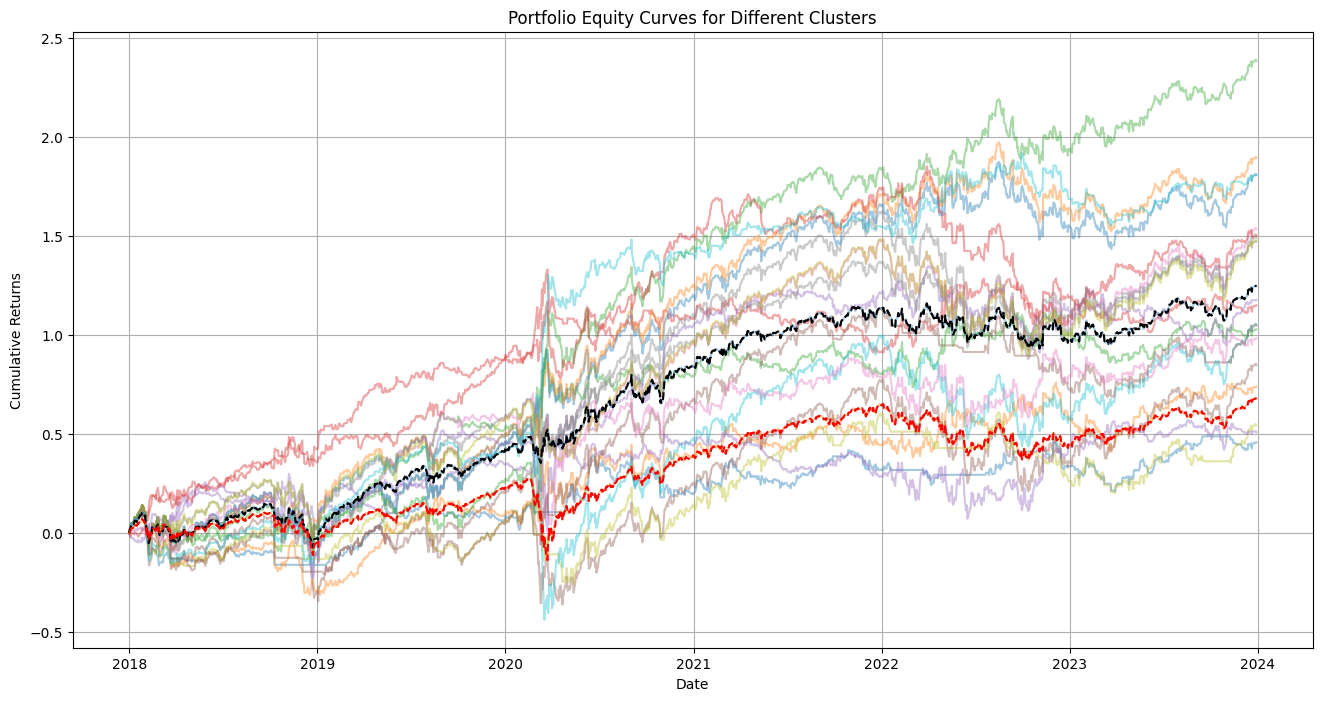

In [ ]:
plt.figure(figsize=(16, 8))

# Select equity curve columns
equity_cols = [col for col in df_portfolios_train.columns if 'equity_curve' in col]

for col in equity_cols:
    # Prepend a zero to the equity curve
    curve = df_portfolios_train[col]
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, label=col, alpha=0.4)

# Overlay portfolio equity curve
if 'Portfolio_equity_curve' in df_portfolios_train.columns:
    curve = df_portfolios_train['Portfolio_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, linestyle='--', color='black', label="Portfolio")


if 'BENCH_equity_curve' in df_portfolios_train.columns:
    curve = df_portfolios_train['BENCH_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, linestyle='--', color='red', label="Portfolio")


#plt.plot(curve_with_zero.index, df_portfolios_train['BENCH_equity_curve'], linestyle='--', color='red', label="Portfolio")

plt.title("Portfolio Equity Curves for Different Clusters")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
#plt.legend()
plt.grid(True)
plt.show()

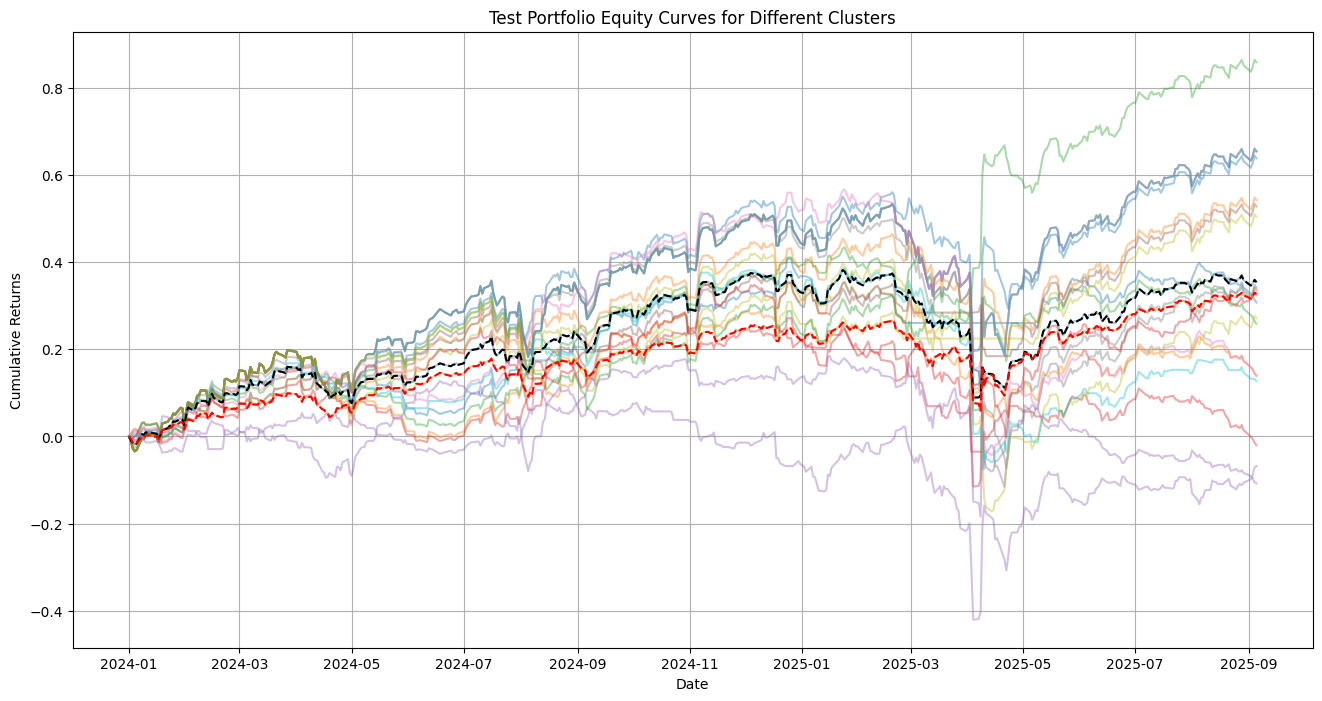

In [ ]:
# Visualize equity curves for all clustering strategies (Test Set)
# This shows out-of-sample performance
plt.figure(figsize=(16, 8))

# Select all equity curve columns in test set
equity_cols_test = [col for col in df_portfolios_test.columns if 'equity_curve' in col]

# Plot equity curves for each clustering method (semi-transparent)
for col in equity_cols_test:
    curve = df_portfolios_test[col]
    # Prepend zero to start from origin
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, label=col, alpha=0.4, linewidth=1)

# Highlight ensemble portfolio
if 'Portfolio_equity_curve' in df_portfolios_test.columns:
    curve = df_portfolios_test['Portfolio_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, 
             linestyle='--', color='black', linewidth=2, label="Ensemble Portfolio")

# Highlight benchmark (buy-and-hold SPY)
if 'BENCH_equity_curve' in df_portfolios_test.columns:
    curve = df_portfolios_test['BENCH_equity_curve']
    curve_with_zero = pd.concat(
        [pd.Series([0], index=[curve.index[0] - pd.Timedelta(days=1)]), curve]
    )
    plt.plot(curve_with_zero.index, curve_with_zero.values, 
             linestyle='--', color='red', linewidth=2, label="Benchmark (SPY)")

plt.title("Test Set: Portfolio Equity Curves for Different Clustering Methods")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 10.00 | Markowitz Portfolio Optimization

Apply Modern Portfolio Theory to construct optimal portfolios:
- **Minimum Variance Portfolio (MVP)**: Minimizes portfolio volatility
- **Tangency Portfolio**: Maximizes Sharpe ratio (risk-adjusted returns)

These portfolios combine all cluster-based strategies using mean-variance optimization.

In [ ]:
def build_markowitz_portfolios(df_train, df_test, freq=252, rf=0.0, min_alloc=0.0, allow_short=False):
    """
    Build Minimum Variance and Tangency Portfolios from log return columns.

    Args:
        df_train (pd.DataFrame): Train set with '_returns' columns
        df_test (pd.DataFrame): Test set with '_returns' columns
        freq (int): Annualization factor (default 252 for daily returns)
        rf (float): Risk-free rate (annualized)
        min_alloc (float): Minimum allocation for long positions
        allow_short (bool): Whether to allow short positions (negative weights)

    Returns:
        df_train_out, df_test_out, weights_mvp, weights_tangency
    """
    df_train_out = df_train.copy()
    df_test_out  = df_test.copy()

    # --- Select return columns ---
    return_cols_train = [c for c in df_train_out.columns if "_returns" in c]
    return_cols_test  = [c for c in df_test_out.columns if "_returns" in c]

    returns_train = df_train_out[return_cols_train]
    returns_test  = df_test_out[return_cols_test]

    # --- Train statistics ---
    mu = returns_train.mean()
    cov = returns_train.cov()

    # --- Set bounds based on min allocation and shorting ---
    if allow_short:
        bounds = tuple((-1, 1) for _ in range(len(mu)))  # allow full short
    else:
        bounds = tuple((min_alloc, 1.0) for _ in range(len(mu)))  # long-only with min allocation

    # Constraint: fully invested
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

    init_guess = np.ones(len(mu)) / len(mu)

    # --- Minimum Variance Portfolio ---
    def portfolio_variance(weights, cov):
        return weights.T @ cov.values @ weights

    res_mvp = minimize(portfolio_variance, init_guess, args=(cov,), method='SLSQP', bounds=bounds, constraints=constraints)
    weights_mvp = pd.Series(res_mvp.x, index=return_cols_train)

    # --- Tangency Portfolio ---
    def neg_sharpe(weights, mu, cov, freq=freq, rf=rf):
        port_return = np.sum(weights * mu) * freq
        port_vol = np.sqrt(weights.T @ cov.values @ weights) * np.sqrt(freq)
        return -(port_return - rf) / port_vol

    res_tangency = minimize(neg_sharpe, init_guess, args=(mu, cov), method='SLSQP', bounds=bounds, constraints=constraints)
    weights_tangency = pd.Series(res_tangency.x, index=return_cols_train)

    # --- Portfolio returns & equity curves ---
    df_train_out['mvp_portfolio_returns'] = returns_train @ weights_mvp
    df_train_out['mvp_portfolio_equity_curve'] = df_train_out['mvp_portfolio_returns'].cumsum()

    df_train_out['tangency_portfolio_returns'] = returns_train @ weights_tangency
    df_train_out['tangency_portfolio_equity_curve'] = df_train_out['tangency_portfolio_returns'].cumsum()

    df_test_out['mvp_portfolio_returns'] = returns_test @ weights_mvp
    df_test_out['mvp_portfolio_equity_curve'] = df_test_out['mvp_portfolio_returns'].cumsum()

    df_test_out['tangency_portfolio_returns'] = returns_test @ weights_tangency
    df_test_out['tangency_portfolio_equity_curve'] = df_test_out['tangency_portfolio_returns'].cumsum()

    return df_train_out, df_test_out, weights_mvp, weights_tangency


In [ ]:
# Build Markowitz-optimized portfolios (MVP and Tangency)
# These portfolios optimally combine all cluster-based strategies
df_portfolios_train_2, df_portfolios_test_2, w_mvp, w_tangency = build_markowitz_portfolios(
    df_portfolios_train, df_portfolios_test
)

# Uncomment to view optimal weights:
# print("Minimum Variance Portfolio Weights:\n", w_mvp)
# print("\nTangency Portfolio Weights:\n", w_tangency)



In [ ]:
# Calculate performance metrics for Markowitz-optimized portfolios
df_metrics_train_2 = Calculate_fin_metrics(df_portfolios_train_2)
df_metrics_test_2 = Calculate_fin_metrics(df_portfolios_test_2)

In [ ]:
# Sort training metrics by Sharpe Ratio for Markowitz portfolios
df_metrics_train_2 = df_metrics_train_2.sort_values(by="Sharpe Ratio", ascending=False)
df_metrics_train_2

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
tangency_portfolio,3.632,0.292,0.011,0.167,1.535,2.174,1.424,-0.205,0.292,1.011,12.302,-0.014,-0.023,0.551
Cluster_SP12,9.857,0.489,0.021,0.336,1.186,1.683,1.760,-0.278,0.489,0.523,8.373,-0.031,-0.047,0.547
Cluster_Birch12,5.116,0.353,0.018,0.293,1.034,1.346,1.145,-0.308,0.353,1.178,13.890,-0.027,-0.042,0.545
Portfolio,2.477,0.231,0.013,0.214,0.974,1.275,1.134,-0.204,0.231,-0.179,4.389,-0.022,-0.033,0.545
mvp_portfolio,2.388,0.226,0.013,0.210,0.970,1.271,1.112,-0.203,0.226,-0.225,4.137,-0.022,-0.032,0.545
Cluster_SP9,5.650,0.372,0.021,0.336,0.941,1.252,1.025,-0.363,0.372,-0.218,3.911,-0.034,-0.051,0.548
Cluster_SP7,5.093,0.352,0.022,0.342,0.883,1.170,0.990,-0.356,0.352,-0.215,3.889,-0.034,-0.052,0.551
Cluster_BayesGMM,3.497,0.285,0.018,0.290,0.866,1.091,0.512,-0.558,0.285,-0.318,5.911,-0.027,-0.045,0.524
Cluster_Birch7,3.355,0.279,0.021,0.330,0.744,0.912,0.776,-0.359,0.279,-0.459,6.170,-0.034,-0.052,0.547


---

## Conclusion & Summary

This notebook demonstrates a comprehensive **cluster-based portfolio optimization framework** that:

### Key Achievements:

1. **Feature Engineering**: Extracted 100+ technical indicators from price and volume data
2. **Dimensionality Reduction**: Applied PCA to reduce noise and focus on important patterns
3. **Market Regime Identification**: Used 8+ clustering algorithms to identify distinct market states
4. **Portfolio Optimization**: Optimized weights for each regime to maximize returns
5. **Performance Evaluation**: Compared strategies using comprehensive financial metrics

### Methodology:

- **Data**: Historical market data (2010-2026) for AAPL and SPY
- **Features**: Technical indicators (RSI, MACD, Bollinger Bands, etc.) + statistical features
- **Clustering**: Multiple algorithms (K-Means, DBSCAN, OPTICS, Spectral, etc.)
- **Optimization**: Cluster-specific weight optimization + Markowitz portfolio theory
- **Evaluation**: Sharpe, Sortino, Calmar ratios, drawdowns, and equity curves

### Insights:

- Different clustering methods identify different market regimes
- Cluster-optimized portfolios can potentially outperform buy-and-hold strategies
- Ensemble approaches (averaging multiple methods) may provide more robust results
- Markowitz optimization provides additional risk-return tradeoff improvements

### Next Steps:

- **Hyperparameter Tuning**: Optimize clustering parameters and PCA components
- **Feature Selection**: Identify most predictive features for each regime
- **Risk Management**: Add stop-loss, position sizing, and risk limits
- **Live Trading**: Implement real-time regime detection and portfolio rebalancing
- **Multi-Asset**: Extend to portfolios with multiple assets

---

**Note**: This framework is for research and educational purposes. Always perform thorough backtesting and risk analysis before deploying any trading strategy.

---

*Happy Trading! 📈*

In [ ]:
# Sort test metrics by Sharpe Ratio for Markowitz portfolios
df_metrics_test_2 = df_metrics_test_2.sort_values(by="Sharpe Ratio", ascending=False)
df_metrics_test_2

,Total Return,Annualized Return,Volatility,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown,CAGR,Skewness,Kurtosis,VaR 95%,CVaR 95%,Hit Ratio
Column,,,,,,,,,,,,,,
Cluster_SP12,1.362,0.673,0.019,0.294,1.749,2.955,2.941,-0.229,0.673,2.787,30.933,-0.026,-0.035,0.556
Cluster_SP3,0.656,0.353,0.014,0.216,1.400,1.806,2.345,-0.150,0.353,-0.222,2.944,-0.023,-0.033,0.534
Cluster_Birch3,0.696,0.372,0.015,0.244,1.296,1.526,2.215,-0.168,0.372,-0.939,5.994,-0.025,-0.038,0.556
Cluster_SP7,0.894,0.466,0.020,0.323,1.186,1.552,1.522,-0.306,0.466,1.260,25.404,-0.028,-0.045,0.565
Cluster_OPTICS,0.925,0.480,0.021,0.341,1.150,1.437,1.412,-0.340,0.480,0.853,20.825,-0.032,-0.049,0.577
Cluster_DBSCAN,0.925,0.480,0.021,0.341,1.150,1.437,1.412,-0.340,0.480,0.853,20.825,-0.032,-0.049,0.577
BENCH,0.387,0.217,0.011,0.170,1.150,1.437,1.155,-0.188,0.217,0.853,20.825,-0.016,-0.025,0.577
Cluster_SP5,0.925,0.480,0.021,0.341,1.150,1.437,1.412,-0.340,0.480,0.853,20.825,-0.032,-0.049,0.577
Cluster_KM3,0.360,0.202,0.011,0.168,1.095,1.559,1.389,-0.146,0.202,0.515,4.697,-0.015,-0.023,0.539
